In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

TARGETS   = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
HORIZON   = 7
LOOKBACK  = 90
FOURIER_K = 4
LAGS      = (1, 2, 3, 7, 14)
TEST_LEN  = 114

# Границы для физически ограниченных показателей
CLIP_BOUNDS = {
    'meantemp':     (None, None),
    'humidity':     (0, 100),
    'wind_speed':   (0, None),
    'meanpressure': (950, 1050),
}

In [3]:
def load_and_clean(path):
    df = pd.read_csv(path, parse_dates=['date']).set_index('date').asfreq('D')
    df.loc[(df['meanpressure'] < 950) | (df['meanpressure'] > 1100), 'meanpressure'] = np.nan
    df['meanpressure'] = df['meanpressure'].interpolate(method='time').bfill().ffill()
    return df

train = load_and_clean('archive/DailyDelhiClimateTrain.csv')
test  = load_and_clean('archive/DailyDelhiClimateTest.csv')

# ============================================================
# ФИКС: очистка фейковых строк в train
# В датасете DailyDelhiClimate последняя строка train (2017-01-01)
# заполнена placeholder-значениями [10.0, 100.0, 0.0, 1016.0],
# хотя реальные значения этого дня есть в test.
# ============================================================

def fix_fake_rows(train, test, targets):
    """
    Заменяет фейковые placeholder-строки в train реальными значениями из test
    (для дат, которые присутствуют в обоих наборах). Если даты нет в test —
    применяет интерполяцию.
    """
    train = train.copy()
    fake_mask = (
        (train['meantemp'] == 10.0) &
        (train['humidity'] == 100.0) &
        (train['wind_speed'] == 0.0)
    )

    n_fake = int(fake_mask.sum())
    print(f"Найдено фейковых строк в train: {n_fake}")

    if n_fake == 0:
        return train

    print("Фейковые строки:")
    display(train.loc[fake_mask, targets])

    for date in train.index[fake_mask]:
        if date in test.index:
            train.loc[date, targets] = test.loc[date, targets].values
            print(f"  {date.date()}: заменено значениями из test → "
                  f"{test.loc[date, targets].values}")
        else:
            train.loc[date, targets] = np.nan
            print(f"  {date.date()}: нет в test → будет интерполировано")

    # Интерполяция для тех, что не нашлись в test
    train[targets] = (train[targets]
                      .interpolate(method='time')
                      .bfill()
                      .ffill())

    print("\nХвост train после исправления:")
    display(train.iloc[-10:][targets].round(2))
    return train


# Применяем фикс
train = fix_fake_rows(train, test, TARGETS)

# Проверка: значения 2017-01-01 в train и test должны совпадать
assert np.allclose(
    train.loc['2017-01-01', TARGETS].values,
    test.loc['2017-01-01', TARGETS].values
), "Фикс не сработал!"
print("\n✅ Фикс применён: train['2017-01-01'] == test['2017-01-01']")

train_int = train.iloc[:-TEST_LEN]
test_int  = train.iloc[-TEST_LEN:]

print(f"Train: {train.shape}, Internal test: {test_int.shape}")

Найдено фейковых строк в train: 1
Фейковые строки:


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,10.0,100.0,0.0,1016.0


  2017-01-01: заменено значениями из test → [  15.91304348   85.86956522    2.74347826 1018.27777778]

Хвост train после исправления:


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-12-23,15.55,74.70,1.20,1014.25
2016-12-24,17.32,78.64,5.24,1011.32
2016-12-25,14.00,94.30,9.09,1014.35
2016-12-26,17.14,74.86,8.78,1016.95
2016-12-27,16.85,67.55,8.34,1017.20
2016-12-28,17.22,68.04,3.55,1015.57
2016-12-29,15.24,87.86,6.00,1016.90
2016-12-30,14.10,89.67,6.27,1017.90
2016-12-31,15.05,87.00,7.32,1016.10



✅ Фикс применён: train['2017-01-01'] == test['2017-01-01']
Train: (1462, 4), Internal test: (114, 4)


In [4]:
def evaluate(y_true, y_pred, name="model"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}


def fourier_terms(t_index, K=FOURIER_K, period=365.25):
    t = np.asarray(t_index, dtype=float)
    data = {}
    for k in range(1, K + 1):
        data[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        data[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(data)


def add_calendar(df):
    df = df.copy()
    doy = df.index.dayofyear.values
    df['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    return df


def get_d(series):
    """Автоматически подбираем порядок дифференцирования по ADF."""
    if adfuller(series.dropna())[1] <= 0.05:
        return 0
    if adfuller(series.diff().dropna())[1] <= 0.05:
        return 1
    return 2


def clip_target(arr, target):
    lo, hi = CLIP_BOUNDS[target]
    return np.clip(arr, lo, hi) if lo is not None or hi is not None else arr

In [5]:
def walk_forward_sarimax(series_train, series_test, d,
                         order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                         exog_train=None, exog_test=None):
    history = list(series_train.values)
    hist_exog = exog_train.reset_index(drop=True).copy()
    test_exog = exog_test.reset_index(drop=True).copy()
    preds = []
    for t in range(len(series_test)):
        try:
            m = SARIMAX(
                history,
                exog=hist_exog.iloc[:len(history)].values,
                order=(order[0], d, order[2]),
                seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            yhat = float(m.forecast(steps=1,
                                    exog=test_exog.iloc[[t]].values).iloc[0])
        except Exception:
            yhat = history[-1]
        preds.append(yhat)
        history.append(series_test.values[t])
        hist_exog = pd.concat([hist_exog, test_exog.iloc[[t]]],
                              ignore_index=True)
    return pd.Series(preds, index=series_test.index)


def sarimax_forecast_h(series_train, d, horizon,
                        order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
                        exog_train=None):
    m = SARIMAX(
        series_train.values, exog=exog_train.values,
        order=(order[0], d, order[2]),
        seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    t_future = np.arange(len(series_train), len(series_train) + horizon)
    exog_future = fourier_terms(t_future)
    fc = m.get_forecast(steps=horizon, exog=exog_future.values)
    return np.asarray(fc.predicted_mean).ravel(), np.asarray(fc.conf_int(alpha=0.05))


# Прогон для всех целевых
sarimax_results = {}

for target in TARGETS:
    d = get_d(train_int[target])
    t_tr_int = np.arange(len(train_int))
    t_te_int = np.arange(len(train_int), len(train_int) + len(test_int))
    exog_tr = fourier_terms(t_tr_int)
    exog_te = fourier_terms(t_te_int)

    pred_int = walk_forward_sarimax(
        train_int[target], test_int[target], d=d,
        exog_train=exog_tr, exog_test=exog_te
    )
    metrics = evaluate(test_int[target].values, pred_int.values,
                       f"SARIMAX [{target}]")

    # Финальный 7-дневный прогноз
    exog_full = fourier_terms(np.arange(len(train)))
    mean7, ci7 = sarimax_forecast_h(train[target], d=d, horizon=HORIZON,
                                    exog_train=exog_full)
    mean7 = clip_target(mean7, target)

    sarimax_results[target] = {"metrics": metrics, "forecast7": mean7, "ci7": ci7}
    print(f"[{target:<13s}] SARIMAX  MAPE={metrics['MAPE']:.2f}%")

[meantemp     ] SARIMAX  MAPE=4.41%
[humidity     ] SARIMAX  MAPE=8.35%
[wind_speed   ] SARIMAX  MAPE=66.35%
[meanpressure ] SARIMAX  MAPE=0.12%


In [6]:
def prep_prophet_lags(df, lags):
    d = df.copy()
    for l in lags:
        d[f'lag_{l}'] = d['y'].shift(l)
    return d.dropna().reset_index(drop=True)


def fit_prophet_lags(train_lagged, lag_cols):
    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.01,
                seasonality_prior_scale=0.1)
    for c in lag_cols:
        m.add_regressor(c)
    m.fit(train_lagged)
    return m


def walk_forward_prophet_lags(train_df, test_df, lags=LAGS):
    lag_cols = [f'lag_{l}' for l in lags]
    history = train_df[['ds', 'y']].copy()
    preds = []
    for i in range(len(test_df)):
        m = fit_prophet_lags(prep_prophet_lags(history, lags), lag_cols)
        row = {'ds': test_df['ds'].iloc[i]}
        for l in lags:
            row[f'lag_{l}'] = history['y'].values[-l]
        preds.append(m.predict(pd.DataFrame([row]))['yhat'].iloc[0])
        history = pd.concat([history, test_df[['ds', 'y']].iloc[[i]]],
                             ignore_index=True)
    return pd.Series(preds, index=test_df['ds'].values)


def prophet_forecast_h(train_df_full, horizon=HORIZON, lags=LAGS):
    lag_cols = [f'lag_{l}' for l in lags]
    m = fit_prophet_lags(prep_prophet_lags(train_df_full, lags), lag_cols)
    last_ds = train_df_full['ds'].iloc[-1]
    last_y = list(train_df_full['y'].values)
    preds = []
    for h in range(1, horizon + 1):
        row = {'ds': last_ds + pd.Timedelta(days=h)}
        for l in lags:
            row[f'lag_{l}'] = last_y[-l]
        yhat = m.predict(pd.DataFrame([row]))['yhat'].iloc[0]
        preds.append(yhat)
        last_y.append(yhat)
    return np.array(preds)


prophet_results = {}

for target in TARGETS:
    tr_int = train_int.reset_index()[['date', target]].rename(
        columns={'date': 'ds', target: 'y'})
    te_int = test_int.reset_index()[['date', target]].rename(
        columns={'date': 'ds', target: 'y'})

    pred_int = walk_forward_prophet_lags(tr_int, te_int)
    metrics = evaluate(test_int[target].values, pred_int.values,
                       f"Prophet [{target}]")

    tr_full = train.reset_index()[['date', target]].rename(
        columns={'date': 'ds', target: 'y'})
    mean7 = clip_target(prophet_forecast_h(tr_full), target)

    prophet_results[target] = {"metrics": metrics, "forecast7": mean7}
    print(f"[{target:<13s}] Prophet  MAPE={metrics['MAPE']:.2f}%")

14:41:13 - cmdstanpy - INFO - Chain [1] start processing
14:41:13 - cmdstanpy - INFO - Chain [1] done processing
14:41:14 - cmdstanpy - INFO - Chain [1] start processing
14:41:14 - cmdstanpy - INFO - Chain [1] done processing
14:41:15 - cmdstanpy - INFO - Chain [1] start processing
14:41:15 - cmdstanpy - INFO - Chain [1] done processing
14:41:15 - cmdstanpy - INFO - Chain [1] start processing
14:41:15 - cmdstanpy - INFO - Chain [1] done processing
14:41:15 - cmdstanpy - INFO - Chain [1] start processing
14:41:16 - cmdstanpy - INFO - Chain [1] done processing
14:41:16 - cmdstanpy - INFO - Chain [1] start processing
14:41:16 - cmdstanpy - INFO - Chain [1] done processing
14:41:16 - cmdstanpy - INFO - Chain [1] start processing
14:41:16 - cmdstanpy - INFO - Chain [1] done processing
14:41:17 - cmdstanpy - INFO - Chain [1] start processing
14:41:17 - cmdstanpy - INFO - Chain [1] done processing
14:41:17 - cmdstanpy - INFO - Chain [1] start processing
14:41:17 - cmdstanpy - INFO - Chain [1]

[meantemp     ] Prophet  MAPE=3.97%


14:42:04 - cmdstanpy - INFO - Chain [1] done processing
14:42:04 - cmdstanpy - INFO - Chain [1] start processing
14:42:04 - cmdstanpy - INFO - Chain [1] done processing
14:42:05 - cmdstanpy - INFO - Chain [1] start processing
14:42:05 - cmdstanpy - INFO - Chain [1] done processing
14:42:05 - cmdstanpy - INFO - Chain [1] start processing
14:42:05 - cmdstanpy - INFO - Chain [1] done processing
14:42:05 - cmdstanpy - INFO - Chain [1] start processing
14:42:05 - cmdstanpy - INFO - Chain [1] done processing
14:42:06 - cmdstanpy - INFO - Chain [1] start processing
14:42:06 - cmdstanpy - INFO - Chain [1] done processing
14:42:06 - cmdstanpy - INFO - Chain [1] start processing
14:42:06 - cmdstanpy - INFO - Chain [1] done processing
14:42:06 - cmdstanpy - INFO - Chain [1] start processing
14:42:07 - cmdstanpy - INFO - Chain [1] done processing
14:42:07 - cmdstanpy - INFO - Chain [1] start processing
14:42:07 - cmdstanpy - INFO - Chain [1] done processing
14:42:07 - cmdstanpy - INFO - Chain [1] 

[humidity     ] Prophet  MAPE=8.34%


14:42:48 - cmdstanpy - INFO - Chain [1] done processing
14:42:49 - cmdstanpy - INFO - Chain [1] start processing
14:42:49 - cmdstanpy - INFO - Chain [1] done processing
14:42:49 - cmdstanpy - INFO - Chain [1] start processing
14:42:49 - cmdstanpy - INFO - Chain [1] done processing
14:42:49 - cmdstanpy - INFO - Chain [1] start processing
14:42:49 - cmdstanpy - INFO - Chain [1] done processing
14:42:50 - cmdstanpy - INFO - Chain [1] start processing
14:42:50 - cmdstanpy - INFO - Chain [1] done processing
14:42:50 - cmdstanpy - INFO - Chain [1] start processing
14:42:50 - cmdstanpy - INFO - Chain [1] done processing
14:42:51 - cmdstanpy - INFO - Chain [1] start processing
14:42:51 - cmdstanpy - INFO - Chain [1] done processing
14:42:51 - cmdstanpy - INFO - Chain [1] start processing
14:42:51 - cmdstanpy - INFO - Chain [1] done processing
14:42:51 - cmdstanpy - INFO - Chain [1] start processing
14:42:51 - cmdstanpy - INFO - Chain [1] done processing
14:42:52 - cmdstanpy - INFO - Chain [1] 

[wind_speed   ] Prophet  MAPE=56.60%


14:43:33 - cmdstanpy - INFO - Chain [1] start processing
14:43:34 - cmdstanpy - INFO - Chain [1] done processing
14:43:34 - cmdstanpy - INFO - Chain [1] start processing
14:43:35 - cmdstanpy - INFO - Chain [1] done processing
14:43:35 - cmdstanpy - INFO - Chain [1] start processing
14:43:35 - cmdstanpy - INFO - Chain [1] done processing
14:43:35 - cmdstanpy - INFO - Chain [1] start processing
14:43:36 - cmdstanpy - INFO - Chain [1] done processing
14:43:36 - cmdstanpy - INFO - Chain [1] start processing
14:43:36 - cmdstanpy - INFO - Chain [1] done processing
14:43:36 - cmdstanpy - INFO - Chain [1] start processing
14:43:37 - cmdstanpy - INFO - Chain [1] done processing
14:43:37 - cmdstanpy - INFO - Chain [1] start processing
14:43:38 - cmdstanpy - INFO - Chain [1] done processing
14:43:38 - cmdstanpy - INFO - Chain [1] start processing
14:43:38 - cmdstanpy - INFO - Chain [1] done processing
14:43:38 - cmdstanpy - INFO - Chain [1] start processing
14:43:39 - cmdstanpy - INFO - Chain [1]

[meanpressure ] Prophet  MAPE=0.12%


In [7]:
NN_FEATURES = TARGETS + ['doy_sin', 'doy_cos']  # 6 признаков на вход
NN_TARGETS  = TARGETS                            # 4 выхода


def build_sequences(X, Y, lookback):
    Xs, Ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i + lookback])
        Ys.append(Y[i + lookback])
    return np.array(Xs), np.array(Ys)


def prepare_multi_nn(train_df, test_df, lookback=LOOKBACK):
    tr_c = add_calendar(train_df)
    te_c = add_calendar(test_df)
    scaler_X = MinMaxScaler().fit(tr_c[NN_FEATURES].values)
    scaler_Y = MinMaxScaler().fit(tr_c[NN_TARGETS].values)

    X_tr = scaler_X.transform(tr_c[NN_FEATURES].values)
    X_te = scaler_X.transform(te_c[NN_FEATURES].values)
    Y_tr = scaler_Y.transform(tr_c[NN_TARGETS].values)
    Y_te = scaler_Y.transform(te_c[NN_TARGETS].values)

    X_full = np.vstack([X_tr, X_te])
    Y_full = np.vstack([Y_tr, Y_te])
    X_all, Y_all = build_sequences(X_full, Y_full, lookback)
    split = len(X_tr) - lookback
    return (X_all[:split], Y_all[:split],
            X_all[split:], Y_all[split:],
            scaler_X, scaler_Y)


def build_multi_rnn(kind='lstm'):
    RNN = LSTM if kind == 'lstm' else GRU
    inp = Input(shape=(LOOKBACK, len(NN_FEATURES)))
    x = RNN(64, return_sequences=True)(inp)
    x = Dropout(0.3)(x)
    x = RNN(32)(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(len(NN_TARGETS))(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='mse', metrics=['mae'])
    return model


def train_multi_rnn(kind, X_tr, Y_tr, X_va, Y_va):
    model = build_multi_rnn(kind)
    es = EarlyStopping(monitor='val_loss', patience=20,
                       restore_best_weights=True, verbose=0)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                           patience=8, min_lr=1e-6, verbose=0)
    model.fit(X_tr, Y_tr, validation_data=(X_va, Y_va),
              epochs=150, batch_size=32, callbacks=[es, rl], verbose=0)
    return model


X_tr, Y_tr, X_te, Y_te, scaler_X, scaler_Y = prepare_multi_nn(train_int, test_int)
vs = int(len(X_tr) * 0.2)
Xtr_, Ytr_ = X_tr[:-vs], Y_tr[:-vs]
Xva_, Yva_ = X_tr[-vs:], Y_tr[-vs:]

lstm_multi = train_multi_rnn('lstm', Xtr_, Ytr_, Xva_, Yva_)
gru_multi  = train_multi_rnn('gru',  Xtr_, Ytr_, Xva_, Yva_)

# Прогноз на внутреннем тесте
pred_lstm_te = scaler_Y.inverse_transform(lstm_multi.predict(X_te, verbose=0))
pred_gru_te  = scaler_Y.inverse_transform(gru_multi.predict(X_te, verbose=0))
Y_te_orig    = scaler_Y.inverse_transform(Y_te)

nn_results = {"LSTM": {}, "GRU": {}}
for i, target in enumerate(TARGETS):
    nn_results["LSTM"][target] = evaluate(
        Y_te_orig[:, i], pred_lstm_te[:, i], f"LSTM [{target}]")
    nn_results["GRU"][target]  = evaluate(
        Y_te_orig[:, i], pred_gru_te[:, i],  f"GRU  [{target}]")
    print(f"[{target:<13s}] LSTM MAPE={nn_results['LSTM'][target]['MAPE']:.2f}%  "
          f"GRU MAPE={nn_results['GRU'][target]['MAPE']:.2f}%")

[meantemp     ] LSTM MAPE=6.04%  GRU MAPE=5.17%
[humidity     ] LSTM MAPE=12.05%  GRU MAPE=9.02%
[wind_speed   ] LSTM MAPE=60.60%  GRU MAPE=60.05%
[meanpressure ] LSTM MAPE=0.16%  GRU MAPE=0.12%


In [8]:
def recursive_multi_rnn_forecast(model, full_df, scaler_X, scaler_Y,
                                 horizon=HORIZON, lookback=LOOKBACK):
    full_c = add_calendar(full_df)
    X_full = scaler_X.transform(full_c[NN_FEATURES].values)
    window = X_full[-lookback:].copy()
    last_date = full_df.index[-1]
    # последние климатические значения (для остальных признаков)
    clim_last = X_full[-1, :len(TARGETS)]

    preds_all = []
    for h in range(1, horizon + 1):
        yhat_scaled = model.predict(window.reshape(1, lookback, -1),
                                    verbose=0)[0]       # 4 значения
        preds_all.append(yhat_scaled)

        # Для следующего шага: заменяем климат на предсказанный
        # (все 4 переменные), календарь — на реальную дату
        doy = (last_date + pd.Timedelta(days=h)).dayofyear
        new_step = np.concatenate([
            yhat_scaled,
            [np.sin(2 * np.pi * doy / 365.25),
             np.cos(2 * np.pi * doy / 365.25)]
        ])
        window = np.vstack([window[1:], new_step])

    preds_orig = scaler_Y.inverse_transform(np.array(preds_all))
    return preds_orig  # shape (horizon, 4)


# Переобучаем на полном train
tr_c = add_calendar(train)
scaler_X_full = MinMaxScaler().fit(tr_c[NN_FEATURES].values)
scaler_Y_full = MinMaxScaler().fit(tr_c[NN_TARGETS].values)

X_full = scaler_X_full.transform(tr_c[NN_FEATURES].values)
Y_full = scaler_Y_full.transform(tr_c[NN_TARGETS].values)

X_all, Y_all = build_sequences(X_full, Y_full, LOOKBACK)
vs = int(len(X_all) * 0.2)
Xtr_f, Ytr_f = X_all[:-vs], Y_all[:-vs]
Xva_f, Yva_f = X_all[-vs:], Y_all[-vs:]

lstm_final = train_multi_rnn('lstm', Xtr_f, Ytr_f, Xva_f, Yva_f)
gru_final  = train_multi_rnn('gru',  Xtr_f, Ytr_f, Xva_f, Yva_f)

lstm_fc7 = recursive_multi_rnn_forecast(lstm_final, train,
                                        scaler_X_full, scaler_Y_full)
gru_fc7  = recursive_multi_rnn_forecast(gru_final,  train,
                                        scaler_X_full, scaler_Y_full)

# Клиппинг
for i, target in enumerate(TARGETS):
    lstm_fc7[:, i] = clip_target(lstm_fc7[:, i], target)
    gru_fc7[:, i]  = clip_target(gru_fc7[:, i],  target)

In [9]:
future_dates = pd.date_range(train.index[-1] + pd.Timedelta(days=1),
                             periods=HORIZON, freq='D')

summary_metrics = []
for target in TARGETS:
    summary_metrics.append({**sarimax_results[target]["metrics"],
                            "Target": target})
    summary_metrics.append({**prophet_results[target]["metrics"],
                            "Target": target})
    summary_metrics.append({**nn_results["LSTM"][target], "Target": target})
    summary_metrics.append({**nn_results["GRU"][target],  "Target": target})

summary_metrics = pd.DataFrame(summary_metrics)
pivot = summary_metrics.pivot(index="Model", columns="Target",
                               values="MAPE").round(2)
print("MAPE по всем моделям и переменным (%):")
display(pivot)

MAPE по всем моделям и переменным (%):


Target,humidity,meanpressure,meantemp,wind_speed
Model,,,,
GRU [humidity],9.02,NaN,NaN,NaN
GRU [meanpressure],NaN,0.12,NaN,NaN
GRU [meantemp],NaN,NaN,5.17,NaN
GRU [wind_speed],NaN,NaN,NaN,60.05
LSTM [humidity],12.05,NaN,NaN,NaN
LSTM [meanpressure],NaN,0.16,NaN,NaN
LSTM [meantemp],NaN,NaN,6.04,NaN
LSTM [wind_speed],NaN,NaN,NaN,60.60
Prophet [humidity],8.34,NaN,NaN,NaN


In [10]:
forecasts_all = {}

for target in TARGETS:
    ti = TARGETS.index(target)

    fc = pd.DataFrame({
        "SARIMAX":  sarimax_results[target]["forecast7"],
        "Prophet":  prophet_results[target]["forecast7"],
        "LSTM":     lstm_fc7[:, ti],
        "GRU":      gru_fc7[:, ti],
    }, index=future_dates)

    # Веса по 1/MAPE внутри данной переменной
    mapes = np.array([
        sarimax_results[target]["metrics"]["MAPE"],
        prophet_results[target]["metrics"]["MAPE"],
        nn_results["LSTM"][target]["MAPE"],
        nn_results["GRU"][target]["MAPE"],
    ])
    w = 1.0 / mapes
    w = w / w.sum()

    fc["ENSEMBLE"] = (fc * w).sum(axis=1)
    fc["ENSEMBLE_STRONG"] = (
        fc[["SARIMAX", "Prophet"]] *
        (1.0 / mapes[:2]) / (1.0 / mapes[:2]).sum()
    ).sum(axis=1)

    forecasts_all[target] = fc

    print(f"\n=== {target} — прогноз на 7 дней ===")
    display(fc.round(2))


=== meantemp — прогноз на 7 дней ===


,SARIMAX,Prophet,LSTM,GRU,ENSEMBLE,ENSEMBLE_STRONG
2017-01-02,15.79,15.80,14.37,14.67,15.25,15.79
2017-01-03,15.72,15.71,14.40,14.71,15.23,15.72
2017-01-04,15.65,15.69,14.23,14.74,15.17,15.67
2017-01-05,15.62,15.58,14.04,14.70,15.08,15.60
2017-01-06,15.60,15.48,13.84,14.69,15.01,15.54
2017-01-07,15.57,15.44,13.67,14.70,14.95,15.50
2017-01-08,15.54,15.30,13.52,14.73,14.88,15.41



=== humidity — прогноз на 7 дней ===


,SARIMAX,Prophet,LSTM,GRU,ENSEMBLE,ENSEMBLE_STRONG
2017-01-02,81.96,81.35,79.660004,78.199997,80.39,81.65
2017-01-03,79.80,78.65,77.669998,76.290001,78.18,79.23
2017-01-04,78.00,76.97,77.410004,75.360001,76.93,77.48
2017-01-05,76.81,76.13,77.500000,75.260002,76.36,76.47
2017-01-06,77.18,77.88,77.790001,75.180000,76.98,77.53
2017-01-07,78.19,79.85,78.110001,75.070000,77.84,79.02
2017-01-08,77.80,81.09,78.410004,74.940002,78.10,79.44



=== wind_speed — прогноз на 7 дней ===


,SARIMAX,Prophet,LSTM,GRU,ENSEMBLE,ENSEMBLE_STRONG
2017-01-02,4.58,4.54,4.95,5.10,4.79,4.56
2017-01-03,5.31,4.82,5.08,4.84,5.01,5.05
2017-01-04,5.25,4.50,5.00,4.58,4.82,4.84
2017-01-05,5.17,4.89,4.84,4.36,4.81,5.02
2017-01-06,4.99,5.09,4.65,4.24,4.74,5.04
2017-01-07,4.98,4.81,4.48,4.18,4.61,4.88
2017-01-08,4.60,4.19,4.33,4.16,4.31,4.38



=== meanpressure — прогноз на 7 дней ===


,SARIMAX,Prophet,LSTM,GRU,ENSEMBLE,ENSEMBLE_STRONG
2017-01-02,1018.86,1018.92,1017.599976,1017.049988,1018.14,1018.89
2017-01-03,1018.70,1018.42,1017.559998,1017.169983,1017.99,1018.56
2017-01-04,1018.85,1018.13,1017.739990,1017.179993,1017.99,1018.48
2017-01-05,1018.87,1018.05,1017.960022,1017.200012,1018.02,1018.45
2017-01-06,1018.94,1017.82,1018.169983,1017.219971,1018.03,1018.37
2017-01-07,1018.98,1017.96,1018.349976,1017.219971,1018.11,1018.47
2017-01-08,1019.03,1018.27,1018.500000,1017.200012,1018.23,1018.64


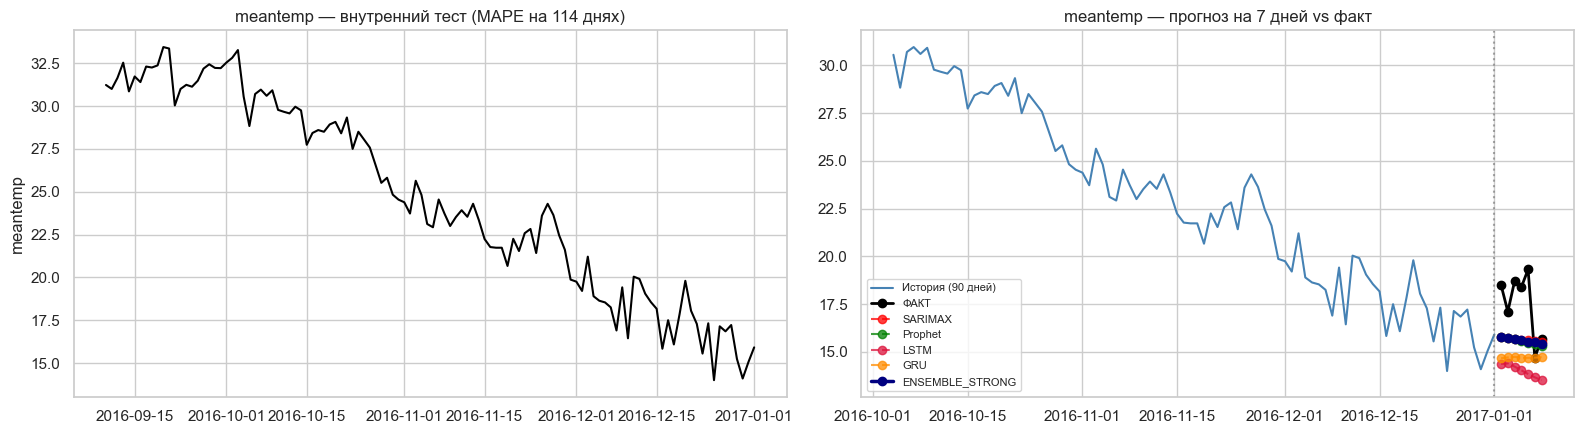

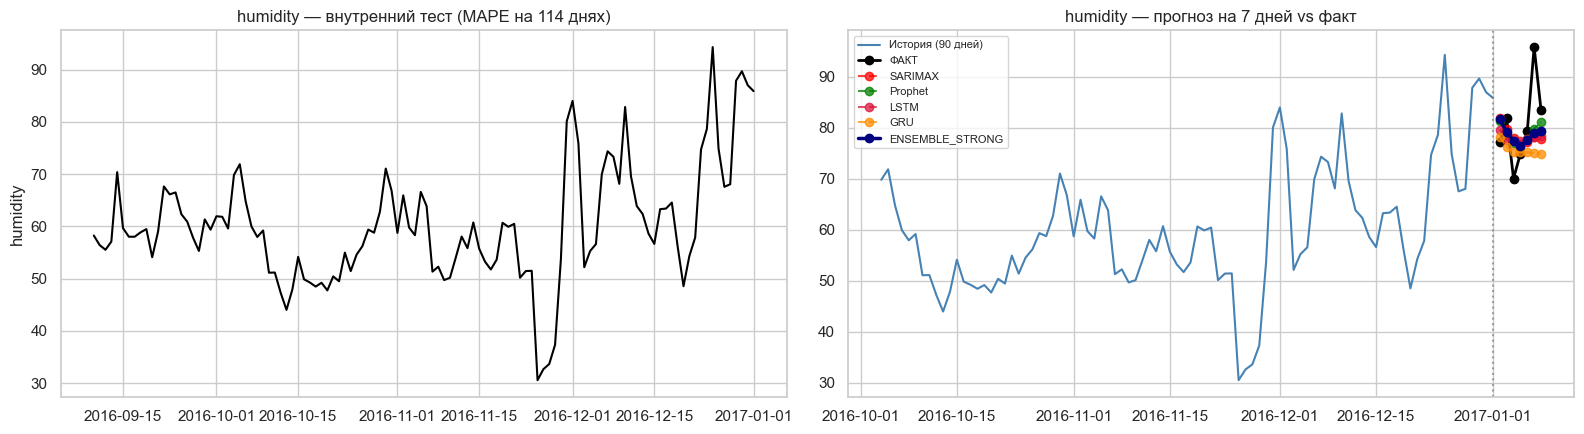

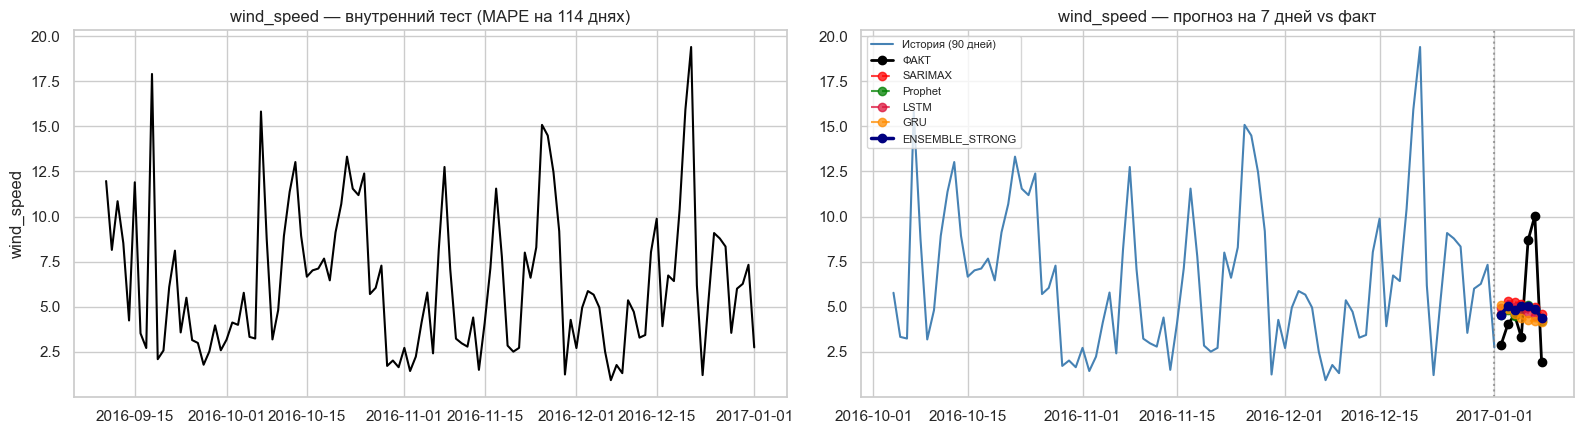

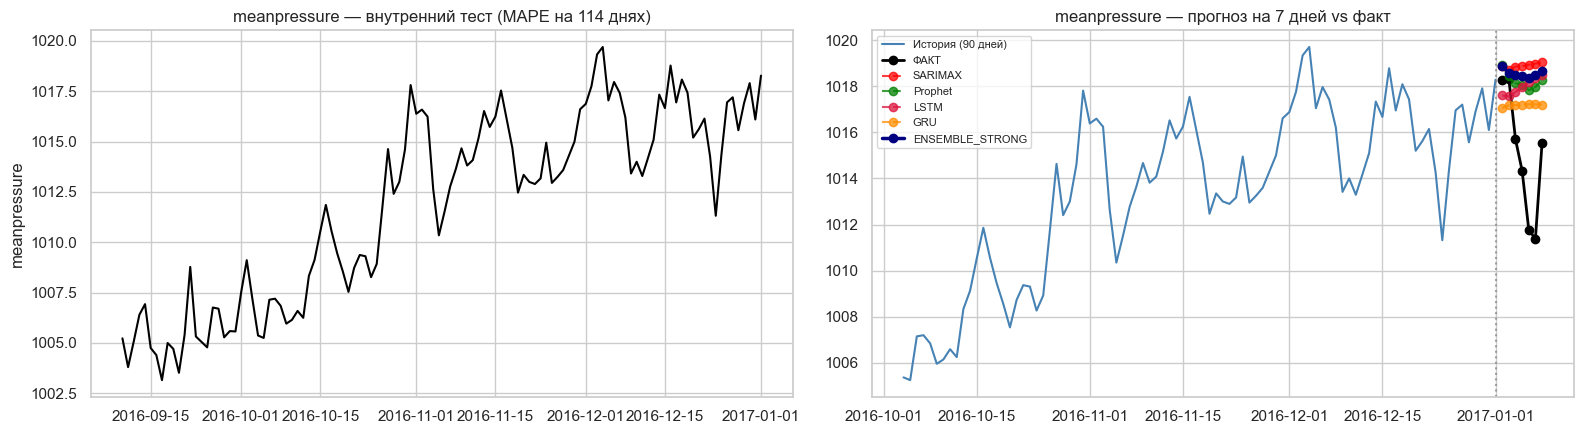

In [11]:
for target in TARGETS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    # --- Внутренний тест ---
    axes[0].plot(test_int.index, test_int[target],
                 color='black', label='Факт', linewidth=1.5)
    axes[0].set_title(f"{target} — внутренний тест (MAPE на 114 днях)")
    axes[0].set_ylabel(target)

    # --- 7-дневный прогноз vs факт (если test известен) ---
    test_sorted = test.sort_index()
    if test_sorted.index[0] == train.index[-1]:
        actual7 = test_sorted.iloc[1:1 + HORIZON][target]
    else:
        actual7 = test_sorted.iloc[:HORIZON][target]

    axes[1].plot(train.index[-90:], train[target].iloc[-90:],
                 color='steelblue', label='История (90 дней)')
    axes[1].plot(actual7.index, actual7.values, '-o', color='black',
                 linewidth=2, label='ФАКТ')
    for col, color in zip(["SARIMAX", "Prophet", "LSTM", "GRU"],
                          ['red', 'green', 'crimson', 'darkorange']):
        axes[1].plot(forecasts_all[target].index,
                     forecasts_all[target][col],
                     '--o', color=color, label=col, alpha=0.75)
    axes[1].plot(forecasts_all[target].index,
                 forecasts_all[target]["ENSEMBLE_STRONG"],
                 '-o', color='navy', linewidth=2.5, label='ENSEMBLE_STRONG')
    axes[1].axvline(train.index[-1], color='gray', ls=':', alpha=0.7)
    axes[1].set_title(f"{target} — прогноз на 7 дней vs факт")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [12]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Проверяем стационарность всех переменных после дифференцирования
print("ADF-тест на дифференцированных рядах:")
for col in TARGETS:
    diff = train[col].diff().dropna()
    pval = adfuller(diff)[1]
    status = "OK" if pval <= 0.05 else "НЕ стационарен"
    print(f"  {col:<14s}: p-value={pval:.6f}  → {status}")

# Для VAR используем лог-преобразование (стабилизирует дисперсию)
# и первые разности (делает ряд стационарным)
# Для humidity и meantemp log может дать проблемы при 0 — используем
# стандартный подход: diff от исходных значений

ADF-тест на дифференцированных рядах:
  meantemp      : p-value=0.000000  → OK
  humidity      : p-value=0.000000  → OK
  wind_speed    : p-value=0.000000  → OK
  meanpressure  : p-value=0.000000  → OK


In [13]:
# Данные для VAR: 4 переменные, первые разности
var_data = train[TARGETS].diff().dropna()

# Выбор порядка по информационным критериям
var_model = VAR(var_data)
lag_order = var_model.select_order(maxlags=15)
print(lag_order.summary())

# Берём порядок по AIC (или BIC, если хотите более консервативно)
best_lag = lag_order.aic
print(f"\nВыбранный порядок VAR по AIC: {best_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        8.647       8.661       5691.       8.652
1        8.482       8.555       4825.       8.509
2        8.259       8.390       3862.       8.308
3        8.152      8.341*       3469.       8.222
4        8.105       8.354       3312.       8.198
5        8.074       8.381       3210.      8.188*
6        8.066       8.431       3184.       8.202
7        8.052       8.475       3140.       8.210
8        8.055       8.536       3149.       8.235
9        8.038       8.578       3097.       8.240
10       8.028       8.627       3067.       8.252
11      8.015*       8.672      3027.*       8.260
12       8.027       8.742       3062.       8.294
13       8.034       8.807       3083.       8.322
14       8.035       8.867       3087.       8.345
15       8.025       8.915       3056.       8.357
-------------------------------

In [14]:
def walk_forward_var(train_series_df, test_series_df, order):
    """
    Walk-forward прогноз VAR на 1 шаг вперёд.
    На каждом шаге модель обучается на всей доступной истории
    и предсказывает следующий день.
    Возвращает DataFrame с прогнозами для всех переменных.
    """
    history = train_series_df.values.copy()
    preds = []
    dates = []

    for t in range(len(test_series_df)):
        model = VAR(history)
        try:
            results = model.fit(order, trend='c')
            yhat = results.forecast(history[-order:], steps=1)[0]
        except Exception:
            # fallback: последнее известное значение
            yhat = history[-1]

        preds.append(yhat)
        dates.append(test_series_df.index[t])

        # Добавляем фактическое значение
        history = np.vstack([history, test_series_df.values[t]])

    preds_df = pd.DataFrame(preds, index=dates, columns=TARGETS)
    return preds_df


# Внутренний тест
var_pred_int = walk_forward_var(train_int[TARGETS], test_int[TARGETS],
                                order=best_lag)

# Метрики по каждой переменной
var_metrics = {}
for target in TARGETS:
    var_metrics[target] = evaluate(
        test_int[target].values,
        var_pred_int[target].values,
        f"VAR [{target}]"
    )
    print(f"[{target:<14s}] VAR MAPE={var_metrics[target]['MAPE']:.2f}%  "
          f"MAE={var_metrics[target]['MAE']:.3f}")

[meantemp      ] VAR MAPE=4.49%  MAE=0.972
[humidity      ] VAR MAPE=8.12%  MAE=4.870
[wind_speed    ] VAR MAPE=66.11%  MAE=2.723
[meanpressure  ] VAR MAPE=0.12%  MAE=1.255


In [15]:
def var_forecast_h(train_df, order, horizon=HORIZON):
    """
    Обучает VAR на полном train и делает прогноз на horizon дней.
    Возвращает:
      - mean: DataFrame (horizon, 4)
      - lower, upper: DataFrames с 95% CI
    """
    data = train_df[TARGETS].diff().dropna()
    model = VAR(data)
    results = model.fit(order, trend='c')

    # Прогноз
    forecast = results.forecast(data.values[-order:], steps=horizon)
    forecast_df = pd.DataFrame(forecast, columns=TARGETS)

    # Доверительные интервалы
    try:
        fc_int = results.forecast_interval(
            data.values[-order:], steps=horizon, alpha=0.05
        )
        lower_df = pd.DataFrame(fc_int[1], columns=TARGETS)
        upper_df = pd.DataFrame(fc_int[2], columns=TARGETS)
    except Exception:
        lower_df = upper_df = None

    # Обратное преобразование: кумулятивная сумма diff + последнее значение
    last_vals = train_df[TARGETS].iloc[-1].values
    forecast_cum = np.cumsum(forecast, axis=0) + last_vals
    forecast_df = pd.DataFrame(forecast_cum, columns=TARGETS)

    if lower_df is not None:
        lower_cum = np.cumsum(fc_int[1], axis=0) + last_vals
        upper_cum = np.cumsum(fc_int[2], axis=0) + last_vals
        lower_df = pd.DataFrame(lower_cum, columns=TARGETS)
        upper_df = pd.DataFrame(upper_cum, columns=TARGETS)

    return forecast_df, lower_df, upper_df


var_fc7, var_lower7, var_upper7 = var_forecast_h(train, order=best_lag)

print("\nVAR — прогноз на 7 дней:")
print(var_fc7.round(2))


VAR — прогноз на 7 дней:
   meantemp  humidity  wind_speed  meanpressure
0     16.06     81.18        5.79       1018.72
1     16.20     79.33        6.53       1017.51
2     16.16     81.11        6.26       1016.23
3     15.99     82.62        5.14       1016.14
4     15.97     81.56        5.50       1016.46
5     15.90     80.92        6.33       1016.99
6     16.08     79.61        6.41       1016.94


In [16]:
# Применяем физические ограничения
for target in TARGETS:
    var_fc7[target] = clip_target(var_fc7[target].values, target)
    if var_lower7 is not None:
        var_lower7[target] = clip_target(var_lower7[target].values, target)
        var_upper7[target] = clip_target(var_upper7[target].values, target)

In [17]:
# --- Собираем все метрики в одну таблицу ---
summary = []

for target in TARGETS:
    # SARIMAX
    summary.append({**sarimax_results[target]["metrics"],
                    "Target": target, "Model": "SARIMAX"})
    # Prophet
    summary.append({**prophet_results[target]["metrics"],
                    "Target": target, "Model": "Prophet"})
    # LSTM
    summary.append({**nn_results["LSTM"][target],
                    "Target": target, "Model": "LSTM"})
    # GRU
    summary.append({**nn_results["GRU"][target],
                    "Target": target, "Model": "GRU"})
    # VAR
    summary.append({**var_metrics[target],
                    "Target": target, "Model": "VAR"})

summary_df = pd.DataFrame(summary)

# Pivot: MAPE по моделям и переменным
pivot_mape = summary_df.pivot_table(
    index="Model", columns="Target", values="MAPE", aggfunc="mean"
).round(2)

# Pivot: MAE
pivot_mae = summary_df.pivot_table(
    index="Model", columns="Target", values="MAE", aggfunc="mean"
).round(3)

print("=" * 70)
print("MAPE (%) по всем моделям и переменным:")
print("=" * 70)
display(pivot_mape)

print("\n" + "=" * 70)
print("MAE по всем моделям и переменным:")
print("=" * 70)
display(pivot_mae)

# --- Ранжирование: средний MAPE по всем переменным ---
avg_mape = summary_df.groupby("Model")["MAPE"].mean().sort_values()
print("\n" + "=" * 70)
print("Средний MAPE по всем переменным (меньше — лучше):")
print("=" * 70)
for model, mape in avg_mape.items():
    print(f"  {model:<10s}: {mape:.2f}%")

MAPE (%) по всем моделям и переменным:


Target,humidity,meanpressure,meantemp,wind_speed
Model,,,,
GRU,9.02,0.12,5.17,60.05
LSTM,12.05,0.16,6.04,60.60
Prophet,8.34,0.12,3.97,56.60
SARIMAX,8.35,0.12,4.41,66.35
VAR,8.12,0.12,4.49,66.11



MAE по всем моделям и переменным:


Target,humidity,meanpressure,meantemp,wind_speed
Model,,,,
GRU,5.246,1.241,1.236,3.110
LSTM,6.723,1.622,1.471,3.369
Prophet,4.792,1.210,0.884,2.913
SARIMAX,5.004,1.239,0.949,2.873
VAR,4.870,1.255,0.972,2.723



Средний MAPE по всем переменным (меньше — лучше):
  Prophet   : 17.26%
  GRU       : 18.59%
  VAR       : 19.71%
  LSTM      : 19.71%
  SARIMAX   : 19.81%


In [18]:
future_dates = pd.date_range(train.index[-1] + pd.Timedelta(days=1),
                             periods=HORIZON, freq='D')

forecasts_all_with_var = {}

for target in TARGETS:
    ti = TARGETS.index(target)

    # VAR прогноз
    var_col = var_fc7[target].values

    fc = pd.DataFrame({
        "SARIMAX":  sarimax_results[target]["forecast7"],
        "Prophet":  prophet_results[target]["forecast7"],
        "LSTM":     lstm_fc7[:, ti],
        "GRU":      gru_fc7[:, ti],
        "VAR":      var_col,
    }, index=future_dates)

    # Веса по 1/MAPE внутри данной переменной
    mapes = np.array([
        sarimax_results[target]["metrics"]["MAPE"],
        prophet_results[target]["metrics"]["MAPE"],
        nn_results["LSTM"][target]["MAPE"],
        nn_results["GRU"][target]["MAPE"],
        var_metrics[target]["MAPE"],
    ])
    w = 1.0 / mapes
    w = w / w.sum()

    fc["ENSEMBLE_ALL"] = (fc * w).sum(axis=1)

    # Ансамбль только из статистических моделей (SARIMAX + Prophet + VAR)
    stat_models = ["SARIMAX", "Prophet", "VAR"]
    stat_mapes = np.array([
        sarimax_results[target]["metrics"]["MAPE"],
        prophet_results[target]["metrics"]["MAPE"],
        var_metrics[target]["MAPE"],
    ])
    w_stat = 1.0 / stat_mapes
    w_stat = w_stat / w_stat.sum()
    fc["ENSEMBLE_STAT"] = (fc[stat_models] * w_stat).sum(axis=1)

    forecasts_all_with_var[target] = fc

    print(f"\n{'='*70}")
    print(f"=== {target} — прогноз на 7 дней (с VAR) ===")
    print(f"{'='*70}")
    display(fc.round(2))


=== meantemp — прогноз на 7 дней (с VAR) ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT
2017-01-02,15.79,15.80,14.37,14.67,16.06,15.42,15.88
2017-01-03,15.72,15.71,14.40,14.71,16.20,15.43,15.87
2017-01-04,15.65,15.69,14.23,14.74,16.16,15.38,15.83
2017-01-05,15.62,15.58,14.04,14.70,15.99,15.27,15.72
2017-01-06,15.60,15.48,13.84,14.69,15.97,15.21,15.67
2017-01-07,15.57,15.44,13.67,14.70,15.90,15.15,15.63
2017-01-08,15.54,15.30,13.52,14.73,16.08,15.13,15.63



=== humidity — прогноз на 7 дней (с VAR) ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT
2017-01-02,81.96,81.35,79.660004,78.199997,81.18,80.56,81.49
2017-01-03,79.80,78.65,77.669998,76.290001,79.33,78.43,79.26
2017-01-04,78.00,76.97,77.410004,75.360001,81.11,77.85,78.72
2017-01-05,76.81,76.13,77.500000,75.260002,82.62,77.74,78.56
2017-01-06,77.18,77.88,77.790001,75.180000,81.56,77.99,78.89
2017-01-07,78.19,79.85,78.110001,75.070000,80.92,78.52,79.66
2017-01-08,77.80,81.09,78.410004,74.940002,79.61,78.43,79.50



=== wind_speed — прогноз на 7 дней (с VAR) ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT
2017-01-02,4.58,4.54,4.95,5.10,5.79,4.98,4.95
2017-01-03,5.31,4.82,5.08,4.84,6.53,5.29,5.52
2017-01-04,5.25,4.50,5.00,4.58,6.26,5.08,5.29
2017-01-05,5.17,4.89,4.84,4.36,5.14,4.87,5.06
2017-01-06,4.99,5.09,4.65,4.24,5.50,4.88,5.19
2017-01-07,4.98,4.81,4.48,4.18,6.33,4.93,5.34
2017-01-08,4.60,4.19,4.33,4.16,6.41,4.70,5.02



=== meanpressure — прогноз на 7 дней (с VAR) ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT
2017-01-02,1018.86,1018.92,1017.599976,1017.049988,1018.72,1018.26,1018.83
2017-01-03,1018.70,1018.42,1017.559998,1017.169983,1017.51,1017.89,1018.22
2017-01-04,1018.85,1018.13,1017.739990,1017.179993,1016.23,1017.63,1017.74
2017-01-05,1018.87,1018.05,1017.960022,1017.200012,1016.14,1017.63,1017.69
2017-01-06,1018.94,1017.82,1018.169983,1017.219971,1016.46,1017.70,1017.75
2017-01-07,1018.98,1017.96,1018.349976,1017.219971,1016.99,1017.88,1017.98
2017-01-08,1019.03,1018.27,1018.500000,1017.200012,1016.94,1017.97,1018.08


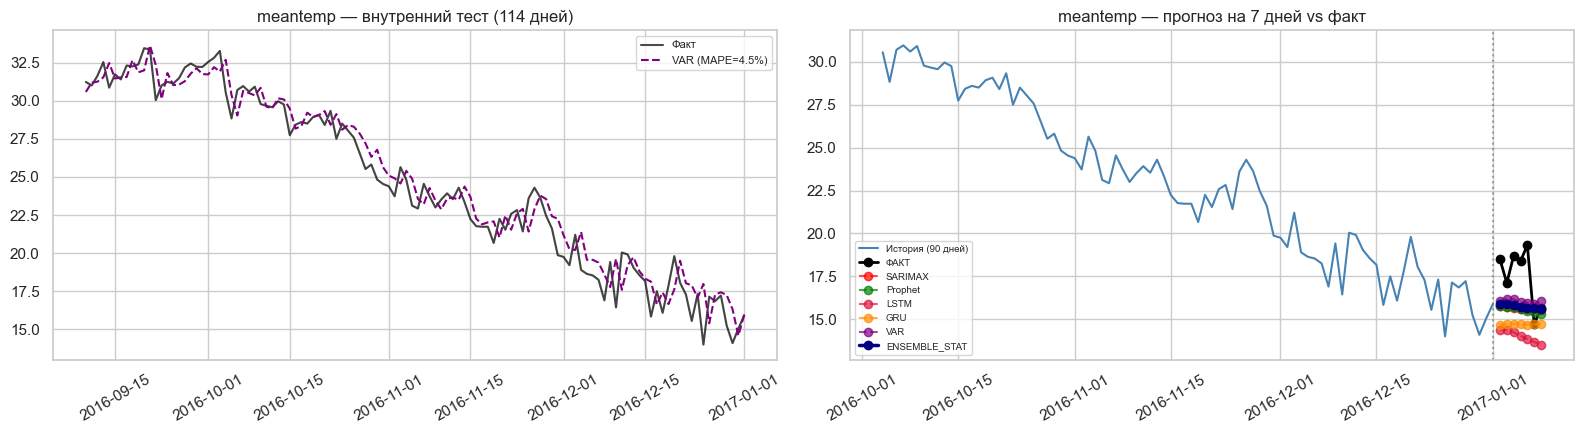

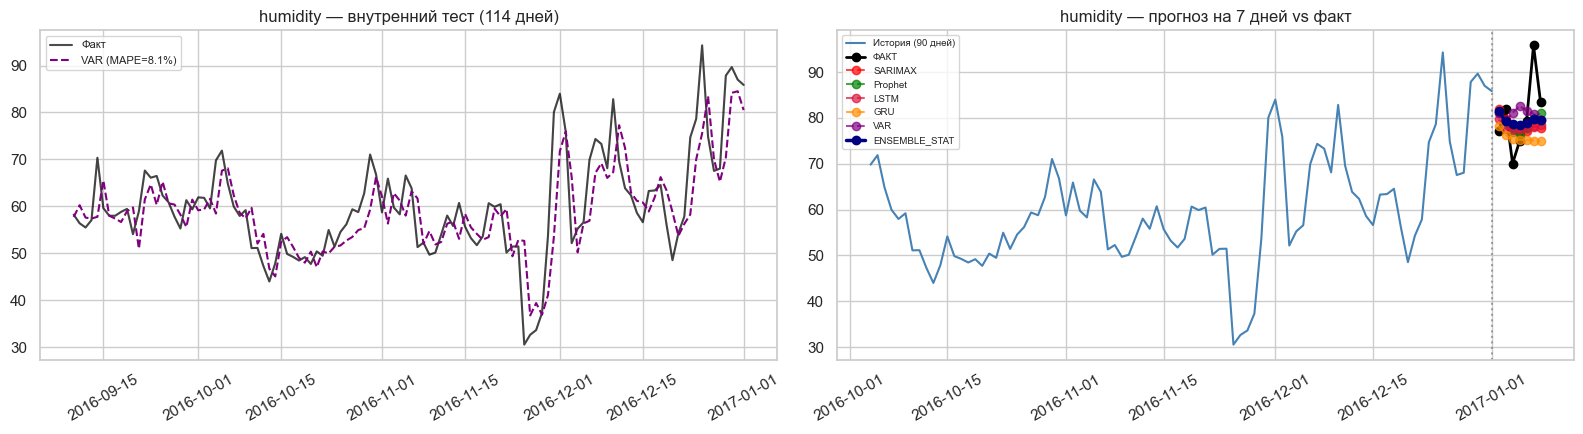

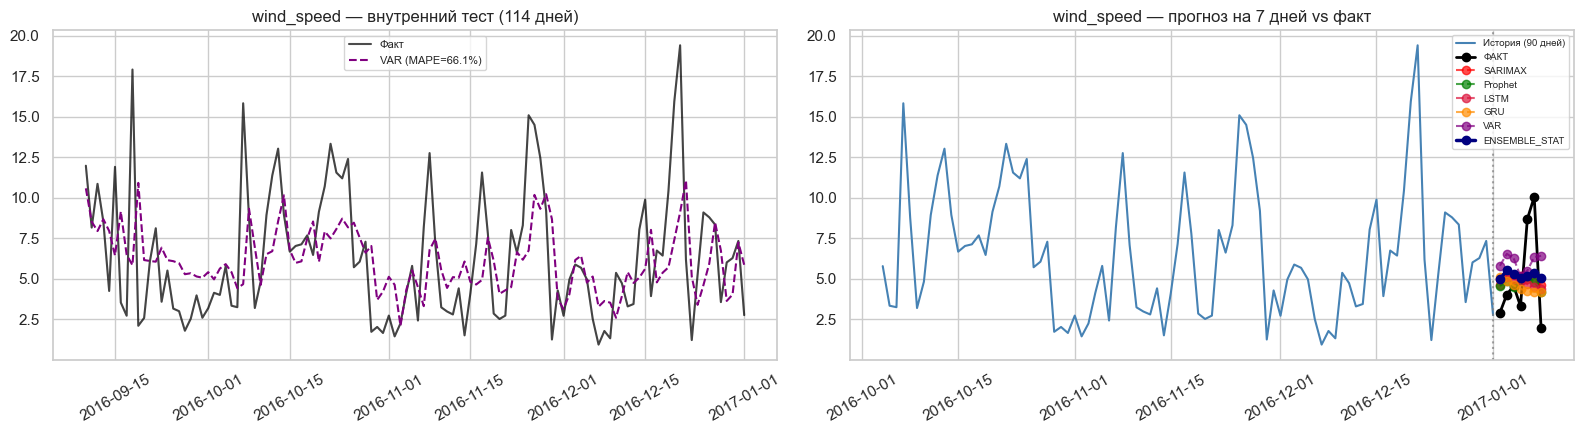

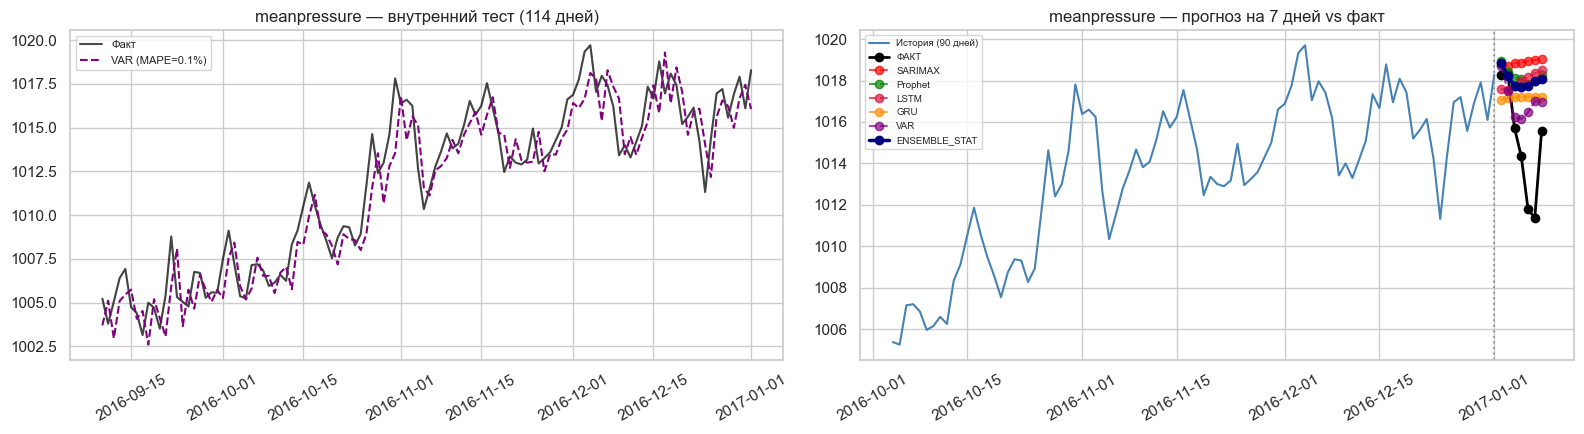

In [19]:
for target in TARGETS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    # --- Внутренний тест: все модели ---
    axes[0].plot(test_int.index, test_int[target],
                 color='black', label='Факт', linewidth=1.5, alpha=0.7)

    # Добавляем прогнозы на внутреннем тесте
    axes[0].plot(test_int.index, test_int[target].values,
                 color='black', alpha=0.1)  # placeholder

    # SARIMAX (walk-forward)
    # (нужно сохранять pred_int для каждой переменной; если не сохранён —
    #  пропускаем и показываем только VAR и финальный прогноз)
    axes[0].plot(var_pred_int.index, var_pred_int[target].values,
                 color='purple', ls='--', label=f'VAR (MAPE={var_metrics[target]["MAPE"]:.1f}%)')
    axes[0].set_title(f"{target} — внутренний тест (114 дней)")
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=30)

    # --- 7-дневный прогноз vs факт ---
    test_sorted = test.sort_index()
    if test_sorted.index[0] == train.index[-1]:
        actual7 = test_sorted.iloc[1:1 + HORIZON][target]
    else:
        actual7 = test_sorted.iloc[:HORIZON][target]

    axes[1].plot(train.index[-90:], train[target].iloc[-90:],
                 color='steelblue', label='История (90 дней)')
    axes[1].plot(actual7.index, actual7.values, '-o', color='black',
                 linewidth=2, label='ФАКТ')

    colors = {'SARIMAX': 'red', 'Prophet': 'green', 'LSTM': 'crimson',
              'GRU': 'darkorange', 'VAR': 'purple'}
    for model, color in colors.items():
        if model in forecasts_all_with_var[target].columns:
            axes[1].plot(forecasts_all_with_var[target].index,
                         forecasts_all_with_var[target][model],
                         '--o', color=color, label=model, alpha=0.7)

    axes[1].plot(forecasts_all_with_var[target].index,
                 forecasts_all_with_var[target]["ENSEMBLE_STAT"],
                 '-o', color='navy', linewidth=2.5, label='ENSEMBLE_STAT')
    axes[1].axvline(train.index[-1], color='gray', ls=':', alpha=0.7)
    axes[1].set_title(f"{target} — прогноз на 7 дней vs факт")
    axes[1].legend(fontsize=7)
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

In [20]:
# --- Загружаем фактические значения из test для первых 7 дней ---
test_sorted = test.sort_index()

# Пропускаем 2017-01-01, если он дублируется в train
if test_sorted.index[0] == train.index[-1]:
    actual7_df = test_sorted.iloc[1:1 + HORIZON]
else:
    actual7_df = test_sorted.iloc[:HORIZON]

print("Фактические значения на 2–8 января 2017:")
display(actual7_df[TARGETS].round(2))


# --- Сравнение по каждой переменной ---
for target in TARGETS:
    fc = forecasts_all_with_var[target].copy()
    fc["ACTUAL"] = actual7_df[target].values

    print(f"\n{'='*70}")
    print(f"=== {target}: прогноз vs факт ===")
    print(f"{'='*70}")
    display(fc.round(2))

    # Ошибки на 7-дневном горизонте
    print(f"\nОшибки на 7-дневном горизонте для {target}:")
    actual = actual7_df[target].values
    for model in fc.columns[:-1]:  # без ACTUAL
        pred = fc[model].values
        mae  = mean_absolute_error(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
        print(f"  {model:<16s}: MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

Фактические значения на 2–8 января 2017:


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-02,18.50,77.22,2.89,1018.28
2017-01-03,17.11,81.89,4.02,1018.33
2017-01-04,18.70,70.05,4.54,1015.70
2017-01-05,18.39,74.94,3.30,1014.33
2017-01-06,19.32,79.32,8.68,1011.77
2017-01-07,14.71,95.83,10.04,1011.38
2017-01-08,15.68,83.53,1.95,1015.55



=== meantemp: прогноз vs факт ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT,ACTUAL
2017-01-02,15.79,15.80,14.37,14.67,16.06,15.42,15.88,18.50
2017-01-03,15.72,15.71,14.40,14.71,16.20,15.43,15.87,17.11
2017-01-04,15.65,15.69,14.23,14.74,16.16,15.38,15.83,18.70
2017-01-05,15.62,15.58,14.04,14.70,15.99,15.27,15.72,18.39
2017-01-06,15.60,15.48,13.84,14.69,15.97,15.21,15.67,19.32
2017-01-07,15.57,15.44,13.67,14.70,15.90,15.15,15.63,14.71
2017-01-08,15.54,15.30,13.52,14.73,16.08,15.13,15.63,15.68



Ошибки на 7-дневном горизонте для meantemp:
  SARIMAX         : MAE=2.092  RMSE=2.415  MAPE=11.45%
  Prophet         : MAE=2.124  RMSE=2.437  MAPE=11.63%
  LSTM            : MAE=3.475  RMSE=3.760  MAPE=19.27%
  GRU             : MAE=2.781  RMSE=3.208  MAPE=15.15%
  VAR             : MAE=1.891  RMSE=2.131  MAPE=10.45%
  ENSEMBLE_ALL    : MAE=2.328  RMSE=2.683  MAPE=12.71%
  ENSEMBLE_STAT   : MAE=2.003  RMSE=2.327  MAPE=10.97%

=== humidity: прогноз vs факт ===


...


Ошибки на 7-дневном горизонте для humidity:
  SARIMAX         : MAE=6.022  RMSE=7.948  MAPE=7.21%
  Prophet         : MAE=5.047  RMSE=6.971  MAPE=6.02%
  LSTM            : MAE=5.849  RMSE=7.810  MAPE=6.97%
  GRU             : MAE=6.527  RMSE=9.122  MAPE=7.61%
  VAR             : MAE=6.618  RMSE=7.986  MAPE=8.19%
  ENSEMBLE_ALL    : MAE=5.877  RMSE=7.740  MAPE=7.04%
  ENSEMBLE_STAT   : MAE=5.685  RMSE=7.475  MAPE=6.88%

=== wind_speed: прогноз vs факт ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT,ACTUAL
2017-01-02,4.58,4.54,4.95,5.10,5.79,4.98,4.95,2.89
2017-01-03,5.31,4.82,5.08,4.84,6.53,5.29,5.52,4.02
2017-01-04,5.25,4.50,5.00,4.58,6.26,5.08,5.29,4.54
2017-01-05,5.17,4.89,4.84,4.36,5.14,4.87,5.06,3.30
2017-01-06,4.99,5.09,4.65,4.24,5.50,4.88,5.19,8.68
2017-01-07,4.98,4.81,4.48,4.18,6.33,4.93,5.34,10.04
2017-01-08,4.60,4.19,4.33,4.16,6.41,4.70,5.02,1.95



Ошибки на 7-дневном горизонте для wind_speed:
  SARIMAX         : MAE=2.423  RMSE=2.799  MAPE=55.92%
  Prophet         : MAE=2.166  RMSE=2.705  MAPE=47.79%
  LSTM            : MAE=2.441  RMSE=2.946  MAPE=54.02%
  GRU             : MAE=2.377  RMSE=3.061  MAPE=50.39%
  VAR             : MAE=2.902  RMSE=3.043  MAPE=79.76%
  ENSEMBLE_ALL    : MAE=2.448  RMSE=2.851  MAPE=57.01%
  ENSEMBLE_STAT   : MAE=2.474  RMSE=2.773  MAPE=60.34%

=== meanpressure: прогноз vs факт ===


,SARIMAX,Prophet,LSTM,GRU,VAR,ENSEMBLE_ALL,ENSEMBLE_STAT,ACTUAL
2017-01-02,1018.86,1018.92,1017.599976,1017.049988,1018.72,1018.26,1018.83,1018.28
2017-01-03,1018.70,1018.42,1017.559998,1017.169983,1017.51,1017.89,1018.22,1018.33
2017-01-04,1018.85,1018.13,1017.739990,1017.179993,1016.23,1017.63,1017.74,1015.70
2017-01-05,1018.87,1018.05,1017.960022,1017.200012,1016.14,1017.63,1017.69,1014.33
2017-01-06,1018.94,1017.82,1018.169983,1017.219971,1016.46,1017.70,1017.75,1011.77
2017-01-07,1018.98,1017.96,1018.349976,1017.219971,1016.99,1017.88,1017.98,1011.38
2017-01-08,1019.03,1018.27,1018.500000,1017.200012,1016.94,1017.97,1018.08,1015.55



Ошибки на 7-дневном горизонте для meanpressure:
  SARIMAX         : MAE=3.840  RMSE=4.662  MAPE=0.38%
  Prophet         : MAE=3.176  RMSE=3.919  MAPE=0.31%
  LSTM            : MAE=3.349  RMSE=4.082  MAPE=0.33%
  GRU             : MAE=2.812  RMSE=3.376  MAPE=0.28%
  VAR             : MAE=2.185  RMSE=2.926  MAPE=0.22%
  ENSEMBLE_ALL    : MAE=2.934  RMSE=3.745  MAPE=0.29%
  ENSEMBLE_STAT   : MAE=3.028  RMSE=3.809  MAPE=0.30%


In [21]:
print("Средняя meantemp за 2–8 января по годам:")
for year in [2013, 2014, 2015, 2016, 2017]:
    try:
        sl = train.loc[f'{year}-01-02':f'{year}-01-08', 'meantemp']
        print(f"  {year}: {sl.mean():.2f} °C")
    except Exception:
        pass
sl = test.loc['2017-01-02':'2017-01-08', 'meantemp']
print(f"  2017 (test): {sl.mean():.2f} °C")

Средняя meantemp за 2–8 января по годам:
  2013: 7.44 °C
  2014: 12.03 °C
  2015: 12.82 °C
  2016: 15.71 °C
  2017: nan °C
  2017 (test): 17.49 °C


In [22]:
last_val = train['meantemp'].iloc[-1]   # ≈ 15.91
naive = np.full(7, last_val)
evaluate(actual7_df['meantemp'].values, naive, "NAIVE (last value)")

{'Model': 'NAIVE (last value)',
 'MAE': 1.983786789107155,
 'RMSE': np.float64(2.2400033615035655),
 'MAPE': np.float64(10.94697568241151)}

In [23]:
def backtest_bias(predict_fn, series, n_recent=60, target=None):
    """
    series: pd.Series (одна колонка) ИЛИ pd.DataFrame (несколько колонок).
    target: имя колонки, если series — DataFrame.
    predict_fn(series_train, horizon) → 1D-массив длины horizon.
    """
    tr = series.iloc[:-n_recent]
    if target is not None:
        val = series[target].iloc[-n_recent:]
    else:
        val = series.iloc[-n_recent:]

    preds = np.asarray(predict_fn(tr, n_recent)).ravel()
    return float(np.mean(val.values - preds))


def residual_series(predict_fn, series, n_recent=60, target=None):
    tr = series.iloc[:-n_recent]
    if target is not None:
        val = series[target].iloc[-n_recent:]
    else:
        val = series.iloc[-n_recent:]

    preds = np.asarray(predict_fn(tr, n_recent)).ravel()
    return pd.Series(val.values - preds, index=val.index)

In [24]:
def yearly_trend(series, month=None):
    """
    Линейный тренд средних значений по годам (°C/год).
    Если month задан — берём только этот месяц.
    """
    yearly = {}
    for y in sorted(set(series.index.year)):
        sl = series.loc[f'{y}-01-01':f'{y}-12-31']
        if month is not None:
            sl = series.loc[f'{y}-{month:02d}-01':f'{y}-{month:02d}-28']
        if len(sl) > 5:
            yearly[y] = sl.mean()

    years = np.array(list(yearly.keys()))
    means = np.array(list(yearly.values()))
    slope = float(np.polyfit(years, means, 1)[0])
    return slope, yearly

In [25]:
def sarimax_predict(tr, h):
    exog = fourier_terms(np.arange(len(tr)))
    m = SARIMAX(tr.values, exog=exog.values,
                order=(1,1,1), seasonal_order=(1,0,1,7),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    exog_f = fourier_terms(np.arange(len(tr), len(tr)+h))
    return np.asarray(m.forecast(steps=h, exog=exog_f.values)).ravel()


bias_sar = backtest_bias(sarimax_predict, train['meantemp'], n_recent=60)
resid_sar = residual_series(sarimax_predict, train['meantemp'], n_recent=60)

print(f"SARIMAX bias на последних 60 днях: {bias_sar:+.2f} °C")

SARIMAX bias на последних 60 днях: +1.43 °C


In [26]:
def prophet_predict(tr, h):
    df = tr.reset_index()[['date', 'meantemp']].rename(
        columns={'date':'ds', 'meantemp':'y'})
    def prep(df, lags):
        d = df.copy()
        for l in lags:
            d[f'lag_{l}'] = d['y'].shift(l)
        return d.dropna().reset_index(drop=True)
    lag_cols = [f'lag_{l}' for l in LAGS]
    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.01,
                seasonality_prior_scale=0.1)
    for c in lag_cols:
        m.add_regressor(c)
    m.fit(prep(df, LAGS))
    last_y = list(df['y'].values)
    last_ds = df['ds'].iloc[-1]
    preds = []
    for hh in range(1, h+1):
        row = {'ds': last_ds + pd.Timedelta(days=hh)}
        for l in LAGS:
            row[f'lag_{l}'] = last_y[-l]
        preds.append(m.predict(pd.DataFrame([row]))['yhat'].iloc[0])
        last_y.append(preds[-1])
    return np.array(preds)


bias_pro = backtest_bias(prophet_predict, train['meantemp'], n_recent=60)
print(f"Prophet bias: {bias_pro:+.2f} °C")

14:57:16 - cmdstanpy - INFO - Chain [1] start processing
14:57:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet bias: +1.35 °C


In [27]:
def var_predict_series(tr, h, var_order=best_lag):
    data = tr[TARGETS].diff().dropna()
    results = VAR(data).fit(var_order, trend='c')
    fc = results.forecast(data.values[-var_order:], steps=h)
    last_vals = tr[TARGETS].iloc[-1].values
    return np.cumsum(fc, axis=0) + last_vals   # (h, 4)


bias_var = backtest_bias(
    lambda tr, h: var_predict_series(tr, h)[:, 0],  # только meantemp
    train, n_recent=60, target='meantemp'
)
print(f"VAR bias: {bias_var:+.2f} °C")

VAR bias: -5.00 °C


In [28]:
slope_jan, yearly_jan = yearly_trend(train['meantemp'], month=1)
print(f"\nТренд января по годам: {slope_jan:+.2f} °C/год")
print(f"Средние января по годам: {yearly_jan}")


Тренд января по годам: +0.83 °C/год
Средние января по годам: {2013: np.float64(11.759948979591837), 2014: np.float64(13.295068027210885), 2015: np.float64(12.713010204081632), 2016: np.float64(14.722852891156462)}


In [29]:
# SARIMAX — series это pd.Series
bias_sar = backtest_bias(sarimax_predict, train['meantemp'], n_recent=60)
resid_sar = residual_series(sarimax_predict, train['meantemp'], n_recent=60)

# Prophet
bias_pro = backtest_bias(prophet_predict, train['meantemp'], n_recent=60)

print(f"SARIMAX bias: {bias_sar:+.2f} °C")
print(f"Prophet bias: {bias_pro:+.2f} °C")
print(f"VAR     bias: {bias_var:+.2f} °C")

14:57:31 - cmdstanpy - INFO - Chain [1] start processing
14:57:31 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX bias: +1.43 °C
Prophet bias: +1.35 °C
VAR     bias: -5.00 °C


In [30]:
# ============================================================
# 1. SARIMAX+Fourier: обучение на train, прогноз на 7 дней
# ============================================================
full_exog = fourier_terms(np.arange(len(train)))

sarimax_full = SARIMAX(
    train['meantemp'].values,
    exog=full_exog.values,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

t_future = np.arange(len(train), len(train) + HORIZON)
exog_future = fourier_terms(t_future)

sarimax_fc = sarimax_full.get_forecast(steps=HORIZON, exog=exog_future.values)
sarimax_mean7 = np.asarray(sarimax_fc.predicted_mean).ravel()
print("SARIMAX raw  :", np.round(sarimax_mean7, 2))


# ============================================================
# 2. Prophet + lags: обучение на train, рекурсивный прогноз
# ============================================================
def prep_prophet_lags(df, lags):
    d = df.copy()
    for l in lags:
        d[f'lag_{l}'] = d['y'].shift(l)
    return d.dropna().reset_index(drop=True)


df_prophet = train.reset_index()[['date', 'meantemp']].rename(
    columns={'date': 'ds', 'meantemp': 'y'})
lag_cols = [f'lag_{l}' for l in LAGS]

m_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=0.1
)
for c in lag_cols:
    m_prophet.add_regressor(c)
m_prophet.fit(prep_prophet_lags(df_prophet, LAGS))

last_ds = df_prophet['ds'].iloc[-1]
last_y = list(df_prophet['y'].values)
prophet_mean7 = []
for h in range(1, HORIZON + 1):
    row = {'ds': last_ds + pd.Timedelta(days=h)}
    for l in LAGS:
        row[f'lag_{l}'] = last_y[-l]
    yhat = m_prophet.predict(pd.DataFrame([row]))['yhat'].iloc[0]
    prophet_mean7.append(yhat)
    last_y.append(yhat)
prophet_mean7 = np.array(prophet_mean7)
print("Prophet raw  :", np.round(prophet_mean7, 2))


# ============================================================
# 3. VAR: обучение на train, прогноз на 7 дней
# ============================================================
data_var = train[TARGETS].diff().dropna()
var_model_full = VAR(data_var).fit(best_lag, trend='c')
var_fc_raw = var_model_full.forecast(data_var.values[-best_lag:], steps=HORIZON)
last_vals_full = train[TARGETS].iloc[-1].values
var_fc7 = pd.DataFrame(
    np.cumsum(var_fc_raw, axis=0) + last_vals_full,
    columns=TARGETS,
    index=pd.date_range(train.index[-1] + pd.Timedelta(days=1),
                        periods=HORIZON, freq='D')
)
print("VAR raw      :", np.round(var_fc7['meantemp'].values, 2))


# ============================================================
# 4. Применяем bias correction
# ============================================================
sarimax_bc   = sarimax_mean7 + bias_sar
prophet_bc   = prophet_mean7 + bias_pro
var_bc       = var_fc7['meantemp'].values + bias_var

# Bias + годовой тренд
year_ahead = 1
sarimax_bc_t = sarimax_mean7 + bias_sar + slope_jan * year_ahead
prophet_bc_t = prophet_mean7 + bias_pro + slope_jan * year_ahead
var_bc_t     = var_fc7['meantemp'].values + bias_var + slope_jan * year_ahead

print(f"\nBias значения: SARIMAX={bias_sar:+.2f}  Prophet={bias_pro:+.2f}  "
      f"VAR={bias_var:+.2f}  |  slope_jan={slope_jan:+.2f} °C/год")
print("SARIMAX+BC   :", np.round(sarimax_bc, 2))
print("SARIMAX+BC+TR:", np.round(sarimax_bc_t, 2))
print("Prophet+BC   :", np.round(prophet_bc, 2))
print("VAR+BC       :", np.round(var_bc, 2))

SARIMAX raw  : [15.79 15.72 15.65 15.62 15.6  15.57 15.54]


14:57:40 - cmdstanpy - INFO - Chain [1] start processing
14:57:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet raw  : [15.8  15.71 15.69 15.58 15.48 15.44 15.3 ]
VAR raw      : [16.06 16.2  16.16 15.99 15.97 15.9  16.08]

Bias значения: SARIMAX=+1.43  Prophet=+1.35  VAR=-5.00  |  slope_jan=+0.83 °C/год
SARIMAX+BC   : [17.22 17.15 17.08 17.05 17.03 17.   16.97]
SARIMAX+BC+TR: [18.05 17.98 17.91 17.88 17.86 17.83 17.8 ]
Prophet+BC   : [17.15 17.07 17.05 16.94 16.83 16.79 16.65]
VAR+BC       : [11.07 11.2  11.16 10.99 10.97 10.9  11.09]


In [31]:
# Фактические значения 02–08.01.2017
test_sorted = test.sort_index()
if test_sorted.index[0] == train.index[-1]:
    actual7_df = test_sorted.iloc[1:1 + HORIZON]
else:
    actual7_df = test_sorted.iloc[:HORIZON]

actual = actual7_df['meantemp'].values
future_dates = actual7_df.index

results_bc = pd.DataFrame({
    'ACTUAL':          actual,
    'SARIMAX':         sarimax_mean7,
    'SARIMAX_BC':      sarimax_bc,
    'SARIMAX_BC+TR':   sarimax_bc_t,
    'Prophet':         prophet_mean7,
    'Prophet_BC':      prophet_bc,
    'Prophet_BC+TR':   prophet_bc_t,
    'VAR':             var_fc7['meantemp'].values,
    'VAR_BC':          var_bc,
    'VAR_BC+TR':       var_bc_t,
}, index=future_dates)

# Ансамбли
results_bc['ENSEMBLE_BC'] = results_bc[
    ['SARIMAX_BC', 'Prophet_BC', 'VAR_BC']].mean(axis=1)
results_bc['ENSEMBLE_BC+TR'] = results_bc[
    ['SARIMAX_BC+TR', 'Prophet_BC+TR', 'VAR_BC+TR']].mean(axis=1)

display(results_bc.round(2))

print("\nMAPE на 7-дневном горизонте (02–08.01.2017):")
for col in results_bc.columns:
    if col == 'ACTUAL':
        continue
    pred = results_bc[col].values
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"  {col:<20s}: MAE={mae:.3f}  MAPE={mape:.2f}%")

,ACTUAL,SARIMAX,SARIMAX_BC,SARIMAX_BC+TR,Prophet,Prophet_BC,Prophet_BC+TR,VAR,VAR_BC,VAR_BC+TR,ENSEMBLE_BC,ENSEMBLE_BC+TR
date,,,,,,,,,,,,
2017-01-02,18.50,15.79,17.22,18.05,15.80,17.15,17.98,16.06,11.07,11.90,15.15,15.98
2017-01-03,17.11,15.72,17.15,17.98,15.71,17.07,17.90,16.20,11.20,12.03,15.14,15.97
2017-01-04,18.70,15.65,17.08,17.91,15.69,17.05,17.88,16.16,11.16,11.99,15.10,15.93
2017-01-05,18.39,15.62,17.05,17.88,15.58,16.94,17.77,15.99,10.99,11.82,14.99,15.82
2017-01-06,19.32,15.60,17.03,17.86,15.48,16.83,17.67,15.97,10.97,11.80,14.94,15.77
2017-01-07,14.71,15.57,17.00,17.83,15.44,16.79,17.63,15.90,10.90,11.73,14.90,15.73
2017-01-08,15.68,15.54,16.97,17.80,15.30,16.65,17.48,16.08,11.09,11.92,14.90,15.73



MAPE на 7-дневном горизонте (02–08.01.2017):
  SARIMAX             : MAE=2.092  MAPE=11.45%
  SARIMAX_BC          : MAE=1.449  MAPE=8.39%
  SARIMAX_BC+TR       : MAE=1.330  MAPE=8.11%
  Prophet             : MAE=2.124  MAPE=11.63%
  Prophet_BC          : MAE=1.433  MAPE=8.21%
  Prophet_BC+TR       : MAE=1.302  MAPE=7.86%
  VAR                 : MAE=1.891  MAPE=10.45%
  VAR_BC              : MAE=6.434  MAPE=36.24%
  VAR_BC+TR           : MAE=5.603  MAPE=31.45%
  ENSEMBLE_BC         : MAE=2.525  MAPE=13.76%
  ENSEMBLE_BC+TR      : MAE=1.945  MAPE=10.67%


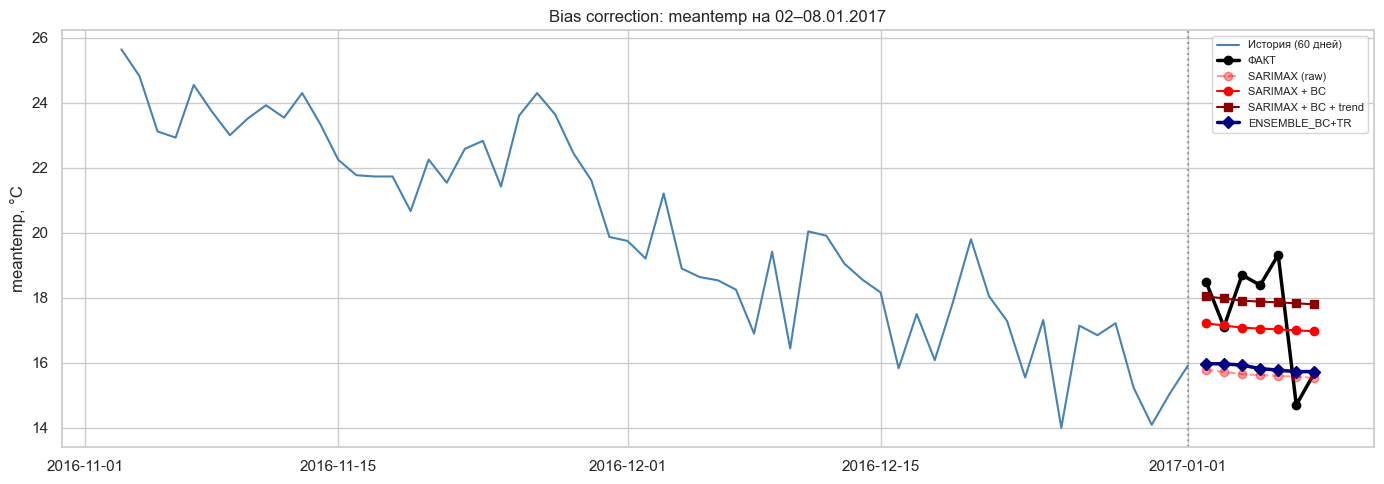

In [32]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train['meantemp'].iloc[-60:],
         color='steelblue', label='История (60 дней)')
plt.plot(actual7_df.index, actual, '-o', color='black',
         linewidth=2.5, label='ФАКТ')

plt.plot(results_bc.index, results_bc['SARIMAX'],
         '--o', color='red', alpha=0.4, label='SARIMAX (raw)')
plt.plot(results_bc.index, results_bc['SARIMAX_BC'],
         '-o', color='red', label='SARIMAX + BC')
plt.plot(results_bc.index, results_bc['SARIMAX_BC+TR'],
         '-s', color='darkred', label='SARIMAX + BC + trend')

plt.plot(results_bc.index, results_bc['ENSEMBLE_BC+TR'],
         '-D', color='navy', linewidth=2.5, label='ENSEMBLE_BC+TR')

plt.axvline(train.index[-1], color='gray', ls=':', alpha=0.7)
plt.title('Bias correction: meantemp на 02–08.01.2017')
plt.ylabel('meantemp, °C')
plt.legend(fontsize=8)
plt.grid(True); plt.tight_layout(); plt.show()

In [33]:
# Усредняем два прогноза
ensemble_final = 0.5 * sarimax_bc_t + 0.5 * prophet_bc_t

final_df = pd.DataFrame({
    'ACTUAL':          actual,
    'SARIMAX_BC+TR':   sarimax_bc_t,
    'Prophet_BC+TR':   prophet_bc_t,
    'ENSEMBLE_FINAL':  ensemble_final,
}, index=future_dates)

display(final_df.round(2))

print("\nMAPE финального ансамбля:")
mae  = mean_absolute_error(actual, ensemble_final)
mape = np.mean(np.abs((actual - ensemble_final) / actual)) * 100
print(f"  ENSEMBLE_FINAL: MAE={mae:.3f}  MAPE={mape:.2f}%")

,ACTUAL,SARIMAX_BC+TR,Prophet_BC+TR,ENSEMBLE_FINAL
date,,,,
2017-01-02,18.50,18.05,17.98,18.02
2017-01-03,17.11,17.98,17.90,17.94
2017-01-04,18.70,17.91,17.88,17.90
2017-01-05,18.39,17.88,17.77,17.82
2017-01-06,19.32,17.86,17.67,17.76
2017-01-07,14.71,17.83,17.63,17.73
2017-01-08,15.68,17.80,17.48,17.64



MAPE финального ансамбля:
  ENSEMBLE_FINAL: MAE=1.316  MAPE=7.98%


In [34]:
# Разница между днём и предыдущим днём (волатильность)
diff_temp = train['meantemp'].diff().dropna()

print(f"std дневного изменения: {diff_temp.std():.2f} °C")
print(f"95-й перцентиль |Δ|:    {diff_temp.abs().quantile(0.95):.2f} °C")
print(f"Максимальный |Δ|:       {diff_temp.abs().max():.2f} °C")

std дневного изменения: 1.67 °C
95-й перцентиль |Δ|:    3.34 °C
Максимальный |Δ|:       10.62 °C


In [35]:
# Разброс прогноза SARIMAX+BC+TR
forecast_std = np.std(sarimax_bc_t)
# Разброс факта
actual_std = np.std(actual7_df['meantemp'].values)

print(f"Разброс прогноза: {forecast_std:.2f}")
print(f"Разброс факта:    {actual_std:.2f}")
print(f"Ratio:            {actual_std / forecast_std:.1f}×")

Разброс прогноза: 0.08
Разброс факта:    1.59
Ratio:            19.9×


In [36]:
def lag_correlation(df, target, predictors, max_lag=5):
    """Кросс-корреляция: corr(target[t], predictor[t-lag])."""
    out = {}
    for p in predictors:
        row = {}
        for lag in range(0, max_lag + 1):
            shifted = df[p].shift(lag)
            row[f'lag_{lag}'] = df[target].corr(shifted)
        out[p] = row
    return pd.DataFrame(out).T.round(3)

predictors = ['meanpressure', 'wind_speed', 'humidity']
corr_table = lag_correlation(train, 'meantemp', predictors, max_lag=5)
display(corr_table)

,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5
meanpressure,-0.879,-0.868,-0.859,-0.852,-0.847,-0.842
wind_speed,0.306,0.287,0.288,0.296,0.297,0.301
humidity,-0.571,-0.541,-0.526,-0.515,-0.509,-0.506


In [37]:
# Корреляция между температурой и давлением внутри одного сезона
for season, months in [('Winter (Jan-Feb)', [1, 2]),
                        ('Spring (Mar-Apr)', [3, 4]),
                        ('Summer (May-Jun)', [5, 6]),
                        ('Monsoon (Jul-Aug)', [7, 8])]:
    mask = train.index.month.isin(months)
    corr = train.loc[mask, 'meantemp'].corr(train.loc[mask, 'meanpressure'])
    print(f"{season:<20s}: corr(meantemp, meanpressure) = {corr:+.3f}")

Winter (Jan-Feb)    : corr(meantemp, meanpressure) = -0.482
Spring (Mar-Apr)    : corr(meantemp, meanpressure) = -0.802
Summer (May-Jun)    : corr(meantemp, meanpressure) = -0.405
Monsoon (Jul-Aug)   : corr(meantemp, meanpressure) = -0.156


In [38]:
# 1. Убираем сезонность через скользящее среднее (или годовой цикл)
#    Простой способ: работаем с первыми разностями
train_diff = train[['meantemp', 'meanpressure', 'wind_speed', 'humidity']].diff().dropna()

def lag_corr_diff(df_diff, target, predictors, max_lag=5):
    out = {}
    for p in predictors:
        row = {}
        for lag in range(0, max_lag + 1):
            row[f'lag_{lag}'] = df_diff[target].corr(df_diff[p].shift(lag))
        out[p] = row
    return pd.DataFrame(out).T.round(3)

corr_diff = lag_corr_diff(train_diff, 'meantemp',
                          ['meanpressure', 'wind_speed', 'humidity'])
print("Кросс-корреляции ДНЕВНЫХ ИЗМЕНЕНИЙ:")
display(corr_diff)

Кросс-корреляции ДНЕВНЫХ ИЗМЕНЕНИЙ:


,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5
meanpressure,-0.312,0.031,0.035,0.059,-0.016,0.020
wind_speed,0.061,-0.081,-0.029,0.033,-0.019,-0.042
humidity,-0.658,0.134,0.027,0.058,0.014,0.046


In [39]:
from statsmodels.tsa.stattools import grangercausalitytests

def granger_test(df, target, predictor, max_lag=5):
    """
    H0: predictor НЕ помогает предсказать target.
    Если p-value < 0.05 — predictor помогает (Granger-причина).
    """
    print(f"\n=== Granger: '{predictor}' → '{target}' ===")
    data = df[[target, predictor]].dropna()
    grangercausalitytests(data, maxlag=max_lag, verbose=True)


# Тестируем на ДИФФЕРЕНЦИРОВАННЫХ данных (иначе будет spurious)
for p in ['meanpressure', 'wind_speed', 'humidity']:
    granger_test(train_diff, 'meantemp', p, max_lag=3)


=== Granger: 'meanpressure' → 'meantemp' ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5853  , p=0.4443  , df_denom=1457, df_num=1
ssr based chi2 test:   chi2=0.5866  , p=0.4438  , df=1
likelihood ratio test: chi2=0.5864  , p=0.4438  , df=1
parameter F test:         F=0.5853  , p=0.4443  , df_denom=1457, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6766  , p=0.5085  , df_denom=1454, df_num=2
ssr based chi2 test:   chi2=1.3578  , p=0.5072  , df=2
likelihood ratio test: chi2=1.3571  , p=0.5073  , df=2
parameter F test:         F=0.6766  , p=0.5085  , df_denom=1454, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5522  , p=0.6467  , df_denom=1451, df_num=3
ssr based chi2 test:   chi2=1.6645  , p=0.6449  , df=3
likelihood ratio test: chi2=1.6635  , p=0.6451  , df=3
parameter F test:         F=0.5522  , p=0.6467  , df_denom=1451, df_num=3

=== Granger: 'wind_speed' → 'meantemp' ==

In [40]:
def forecast_sarimax_with_ci(train_series, horizon, bias=0.0):
    """SARIMAX+Fourier: прогноз + 95% CI с bias correction."""
    exog = fourier_terms(np.arange(len(train_series)))
    m = SARIMAX(
        train_series.values, exog=exog.values,
        order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    t_fut = np.arange(len(train_series), len(train_series) + horizon)
    exog_f = fourier_terms(t_fut)
    fc = m.get_forecast(steps=horizon, exog=exog_f.values)
    mean = np.asarray(fc.predicted_mean).ravel() + bias
    ci = np.asarray(fc.conf_int(alpha=0.05)) + bias
    return mean, ci


def forecast_prophet_with_ci(train_df, horizon, bias=0.0, lags=LAGS):
    """Prophet+lags: рекурсивный прогноз + CI."""
    df = train_df.reset_index()[['date', 'meantemp']].rename(
        columns={'date': 'ds', 'meantemp': 'y'})

    def prep(df, lags):
        d = df.copy()
        for l in lags:
            d[f'lag_{l}'] = d['y'].shift(l)
        return d.dropna().reset_index(drop=True)

    lag_cols = [f'lag_{l}' for l in lags]
    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.01,
                seasonality_prior_scale=0.1)
    for c in lag_cols:
        m.add_regressor(c)
    m.fit(prep(df, lags))

    last_ds = df['ds'].iloc[-1]
    last_y = list(df['y'].values)
    means, lowers, uppers = [], [], []
    for h in range(1, horizon + 1):
        row = {'ds': last_ds + pd.Timedelta(days=h)}
        for l in lags:
            row[f'lag_{l}'] = last_y[-l]
        pred = m.predict(pd.DataFrame([row]))
        yhat = pred['yhat'].iloc[0]
        means.append(yhat)
        lowers.append(pred['yhat_lower'].iloc[0])
        uppers.append(pred['yhat_upper'].iloc[0])
        last_y.append(yhat)

    means = np.array(means) + bias
    lowers = np.array(lowers) + bias
    uppers = np.array(uppers) + bias
    return means, np.column_stack([lowers, uppers])


def ensemble_forecast_with_ci(sar_mean, sar_ci, pro_mean, pro_ci,
                               w_sar=0.5, w_pro=0.5):
    """
    Взвешенный ансамбль с CI через variance propagation.
    Предполагаем независимость ошибок SARIMAX и Prophet.
    """
    mean = w_sar * sar_mean + w_pro * pro_mean
    sigma_sar = (sar_ci[:, 1] - sar_ci[:, 0]) / (2 * 1.96)
    sigma_pro = (pro_ci[:, 1] - pro_ci[:, 0]) / (2 * 1.96)
    sigma_ens = np.sqrt(w_sar**2 * sigma_sar**2 + w_pro**2 * sigma_pro**2)
    lower = mean - 1.96 * sigma_ens
    upper = mean + 1.96 * sigma_ens
    return mean, np.column_stack([lower, upper])


def coverage(actual, lower, upper):
    """Доля фактических значений внутри [lower, upper], %."""
    inside = (actual >= lower) & (actual <= upper)
    return inside.mean() * 100

In [41]:
def walk_forward_block(train_init, test_df, horizon=7,
                       bias_sar=0.0, bias_pro=0.0):
    """
    Блочный walk-forward: каждые `horizon` дней переобучаемся и
    предсказываем следующие `horizon` дней.
    """
    results = []
    history = train_init.copy()
    test_index = test_df.index
    n_test = len(test_index)
    pos = 0
    window_id = 0

    while pos < n_test:
        block_end = min(pos + horizon, n_test)
        block_h = block_end - pos
        window_id += 1
        print(f"  Окно {window_id}: обучение до {history.index[-1].date()}, "
              f"прогноз на {block_h} дней")

        # SARIMAX
        sar_mean, sar_ci = forecast_sarimax_with_ci(
            history['meantemp'], block_h, bias=bias_sar)

        # Prophet
        pro_mean, pro_ci = forecast_prophet_with_ci(
            history, block_h, bias=bias_pro)

        # Ensemble
        ens_mean, ens_ci = ensemble_forecast_with_ci(
            sar_mean, sar_ci, pro_mean, pro_ci)

        for i in range(block_h):
            date = test_index[pos + i]
            results.append({
                'date':        date,
                'window':      window_id,
                'h':           i + 1,
                'sarimax':     sar_mean[i],
                'sar_lo':      sar_ci[i, 0],
                'sar_hi':      sar_ci[i, 1],
                'prophet':     pro_mean[i],
                'pro_lo':      pro_ci[i, 0],
                'pro_hi':      pro_ci[i, 1],
                'ensemble':    ens_mean[i],
                'ens_lo':      ens_ci[i, 0],
                'ens_hi':      ens_ci[i, 1],
                'actual':      test_df.loc[date, 'meantemp'],
            })

        # Добавляем факт в историю
        block_data = test_df.iloc[pos:block_end]
        history = pd.concat([history, block_data])
        pos = block_end

    return pd.DataFrame(results).set_index('date')


print("Запуск walk-forward с шагом 7...")
wf7 = walk_forward_block(
    train_init=train,     # полный train (с исправленной фейковой строкой)
    test_df=test,
    horizon=7,
    bias_sar=bias_sar,    # из предыдущих ячеек
    bias_pro=bias_pro
)
print(f"\n✅ Готово: {len(wf7)} прогнозов, {wf7['window'].nunique()} окон")

Запуск walk-forward с шагом 7...
  Окно 1: обучение до 2017-01-01, прогноз на 7 дней


14:57:48 - cmdstanpy - INFO - Chain [1] start processing
14:57:48 - cmdstanpy - INFO - Chain [1] done processing


  Окно 2: обучение до 2017-01-07, прогноз на 7 дней


14:57:55 - cmdstanpy - INFO - Chain [1] start processing
14:57:55 - cmdstanpy - INFO - Chain [1] done processing


  Окно 3: обучение до 2017-01-14, прогноз на 7 дней


...

  Окно 16: обучение до 2017-04-15, прогноз на 7 дней


14:59:23 - cmdstanpy - INFO - Chain [1] start processing
14:59:23 - cmdstanpy - INFO - Chain [1] done processing


  Окно 17: обучение до 2017-04-22, прогноз на 2 дней


14:59:29 - cmdstanpy - INFO - Chain [1] start processing
14:59:29 - cmdstanpy - INFO - Chain [1] done processing



✅ Готово: 114 прогнозов, 17 окон


In [42]:
actual = wf7['actual'].values

print("=" * 70)
print("ОБЩИЕ МЕТРИКИ на всём test (114 дней):")
print("=" * 70)
for model in ['sarimax', 'prophet', 'ensemble']:
    pred = wf7[model].values
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    cov  = coverage(actual, wf7[f'{model[:3]}_lo'], wf7[f'{model[:3]}_hi']) \
           if model != 'ensemble' else coverage(actual, wf7['ens_lo'], wf7['ens_hi'])
    print(f"  {model:<10s}: MAE={mae:.3f}  RMSE={rmse:.3f}  "
          f"MAPE={mape:.2f}%  Coverage={cov:.1f}%")

ОБЩИЕ МЕТРИКИ на всём test (114 дней):
  sarimax   : MAE=2.240  RMSE=2.745  MAPE=12.36%  Coverage=83.3%
  prophet   : MAE=2.282  RMSE=2.806  MAPE=12.59%  Coverage=51.8%
  ensemble  : MAE=2.256  RMSE=2.771  MAPE=12.46%  Coverage=57.9%



MAPE по горизонту внутри окна (h = 1..7):


,h,N,sarimax,prophet,ensemble
0,1,17,8.04,7.69,7.87
1,2,17,10.13,10.41,10.27
2,3,16,12.85,13.43,13.14
3,4,16,15.63,16.49,16.02
4,5,16,11.08,11.45,11.21
5,6,16,14.70,14.74,14.72
6,7,16,14.48,14.37,14.40


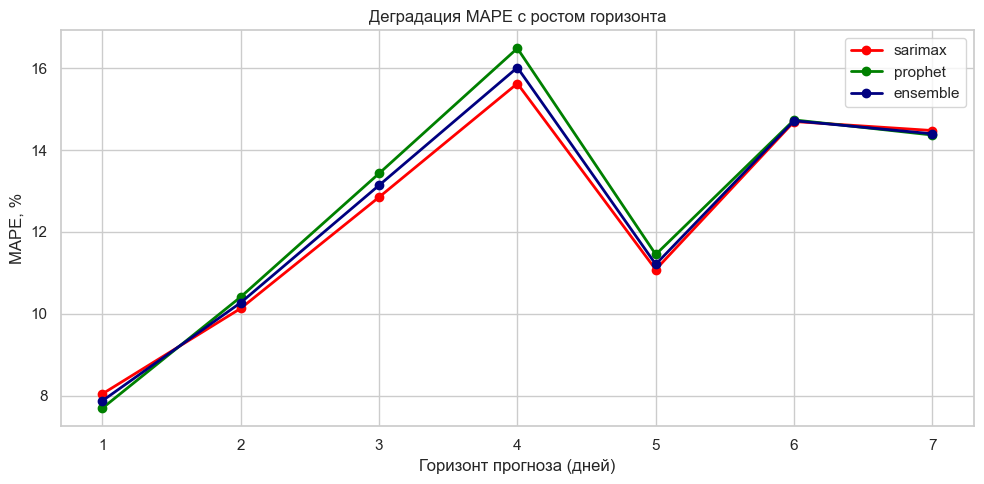

In [43]:
print("\n" + "=" * 70)
print("MAPE по горизонту внутри окна (h = 1..7):")
print("=" * 70)

horizon_metrics = []
for h in range(1, 8):
    sl = wf7[wf7['h'] == h]
    row = {'h': h, 'N': len(sl)}
    for model in ['sarimax', 'prophet', 'ensemble']:
        mape = np.mean(np.abs((sl['actual'] - sl[model]) / sl['actual'])) * 100
        row[model] = mape
    horizon_metrics.append(row)

horizon_df = pd.DataFrame(horizon_metrics).round(2)
display(horizon_df)

# Визуализация
plt.figure(figsize=(10, 5))
for model, color in zip(['sarimax', 'prophet', 'ensemble'],
                         ['red', 'green', 'navy']):
    plt.plot(horizon_df['h'], horizon_df[model], '-o',
             color=color, label=model, linewidth=2)
plt.xlabel('Горизонт прогноза (дней)')
plt.ylabel('MAPE, %')
plt.title('Деградация MAPE с ростом горизонта')
plt.xticks(range(1, 8)); plt.grid(True)
plt.legend(); plt.tight_layout(); plt.show()

In [44]:
print("\n" + "=" * 70)
print("Стабильность по окнам:")
print("=" * 70)

window_metrics = []
for wid, grp in wf7.groupby('window'):
    row = {'window': wid, 'start': grp.index[0].date(),
           'end': grp.index[-1].date(), 'N': len(grp)}
    for model in ['sarimax', 'prophet', 'ensemble']:
        mape = np.mean(np.abs((grp['actual'] - grp[model]) / grp['actual'])) * 100
        row[f'{model}_MAPE'] = mape
    # Coverage для ensemble
    row['ens_cov'] = coverage(grp['actual'].values,
                               grp['ens_lo'].values, grp['ens_hi'].values)
    window_metrics.append(row)

window_df = pd.DataFrame(window_metrics).round(2)
display(window_df)

# Стабильность
print(f"\nСредний MAPE ансамбля по окнам: {window_df['ensemble_MAPE'].mean():.2f}%")
print(f"Стд MAPE ансамбля по окнам:    {window_df['ensemble_MAPE'].std():.2f}%")
print(f"Худшее окно: {window_df.loc[window_df['ensemble_MAPE'].idxmax(), 'start']} "
      f"— {window_df['ensemble_MAPE'].max():.2f}%")
print(f"Лучшее окно: {window_df.loc[window_df['ensemble_MAPE'].idxmin(), 'start']} "
      f"— {window_df['ensemble_MAPE'].min():.2f}%")


Стабильность по окнам:


,window,start,end,N,sarimax_MAPE,prophet_MAPE,ensemble_MAPE,ens_cov
0,1,2017-01-01,2017-01-07,7,8.46,8.58,8.52,85.71
1,2,2017-01-08,2017-01-14,7,31.40,31.07,31.24,14.29
2,3,2017-01-15,2017-01-21,7,17.46,18.78,18.12,57.14
3,4,2017-01-22,2017-01-28,7,10.22,9.95,10.08,71.43
4,5,2017-01-29,2017-02-04,7,10.69,9.97,10.33,71.43
5,6,2017-02-05,2017-02-11,7,25.80,28.10,26.95,14.29
6,7,2017-02-12,2017-02-18,7,8.79,9.66,9.16,42.86
7,8,2017-02-19,2017-02-25,7,11.64,12.00,11.82,42.86
8,9,2017-02-26,2017-03-04,7,10.83,10.62,10.72,57.14
9,10,2017-03-05,2017-03-11,7,16.99,16.24,16.61,14.29



Средний MAPE ансамбля по окнам: 12.17%
Стд MAPE ансамбля по окнам:    8.13%
Худшее окно: 2017-01-08 — 31.24%
Лучшее окно: 2017-04-16 — 2.54%


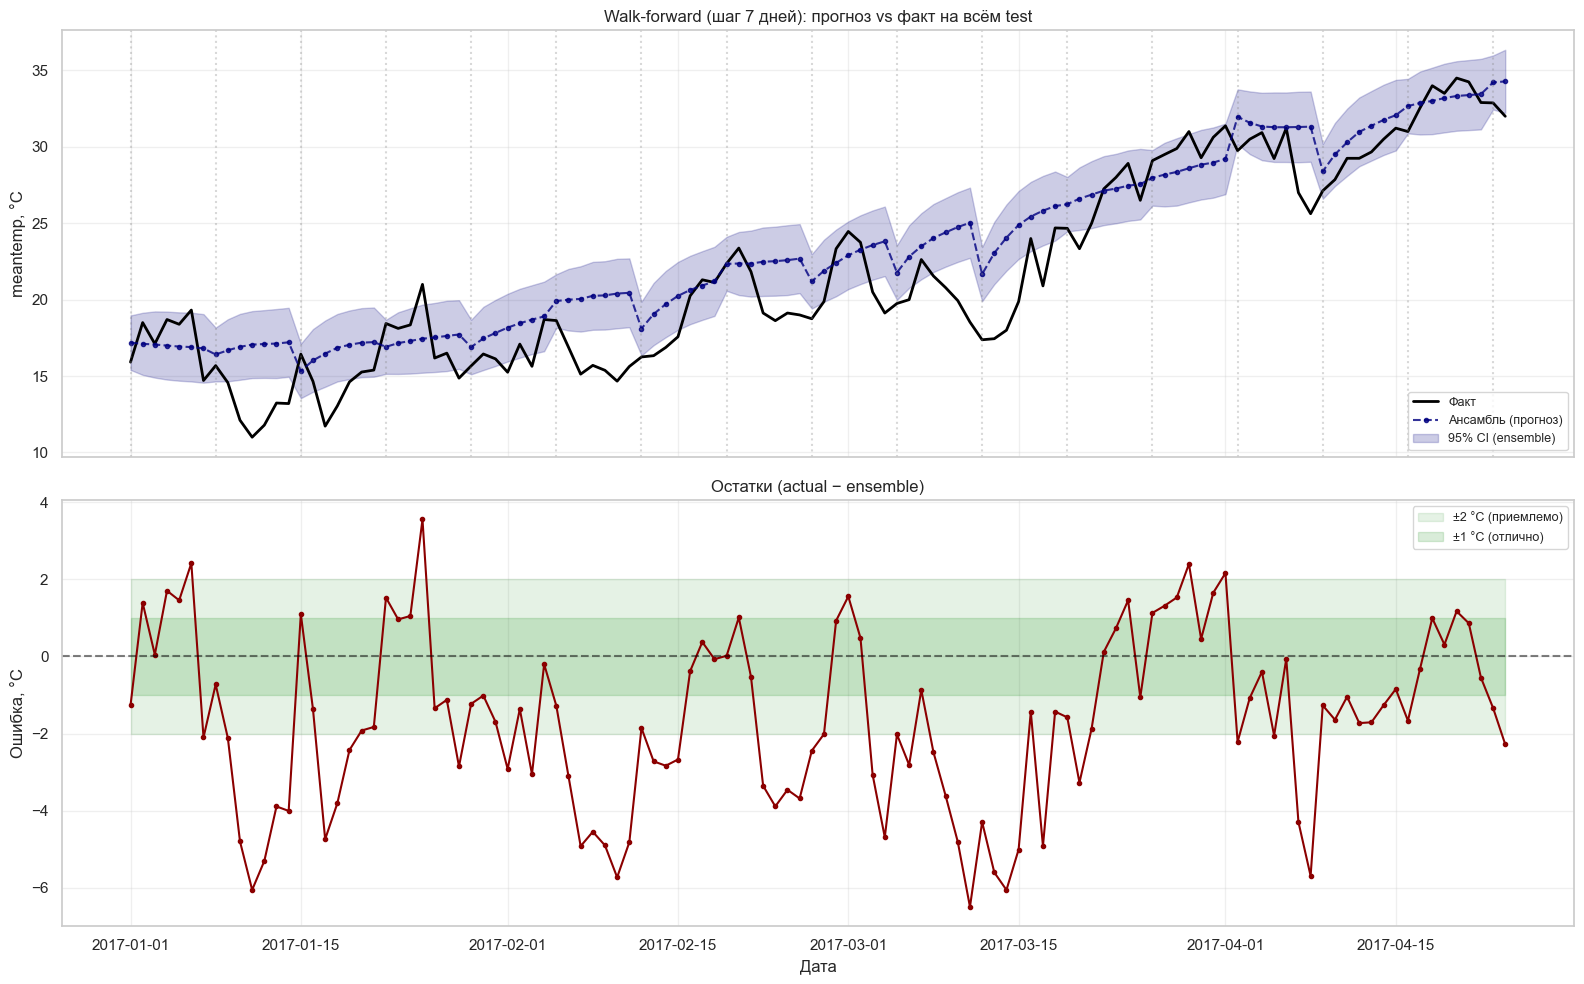

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- 1. Факт + прогноз + CI ---
ax = axes[0]
ax.plot(wf7.index, wf7['actual'], '-', color='black',
        linewidth=2, label='Факт')
ax.plot(wf7.index, wf7['ensemble'], '--o', color='navy',
        markersize=3, label='Ансамбль (прогноз)', alpha=0.8)
ax.fill_between(wf7.index, wf7['ens_lo'], wf7['ens_hi'],
                 alpha=0.2, color='navy', label='95% CI (ensemble)')

# Границы окон
for w_start in wf7.groupby('window').apply(lambda g: g.index[0]):
    ax.axvline(w_start, color='gray', ls=':', alpha=0.3)

ax.set_title('Walk-forward (шаг 7 дней): прогноз vs факт на всём test')
ax.set_ylabel('meantemp, °C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- 2. Ошибка (actual - ensemble) ---
ax = axes[1]
resid = wf7['actual'] - wf7['ensemble']
ax.plot(wf7.index, resid, '-o', color='darkred', markersize=3)
ax.axhline(0, color='black', ls='--', alpha=0.5)
ax.fill_between(wf7.index, -2, 2, alpha=0.1, color='green',
                 label='±2 °C (приемлемо)')
ax.fill_between(wf7.index, -1, 1, alpha=0.15, color='green',
                 label='±1 °C (отлично)')
ax.set_title('Остатки (actual − ensemble)')
ax.set_ylabel('Ошибка, °C')
ax.set_xlabel('Дата')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Coverage 95% CI по горизонту:


,h,N,sarimax,prophet,ensemble
0,1,17,94.1,76.5,70.6
1,2,17,94.1,52.9,58.8
2,3,16,75.0,62.5,68.8
3,4,16,81.2,25.0,37.5
4,5,16,87.5,62.5,68.8
5,6,16,81.2,37.5,43.8
6,7,16,68.8,43.8,56.2


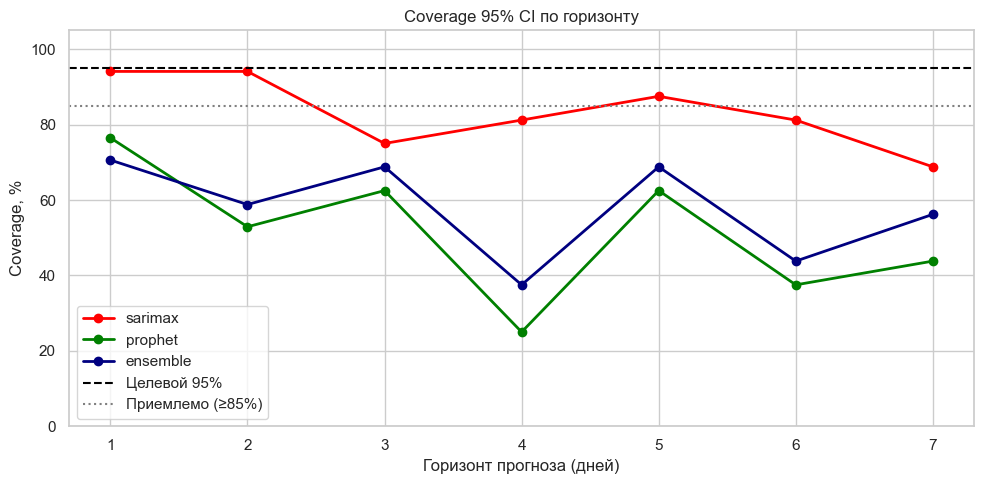

In [46]:
print("\n" + "=" * 70)
print("Coverage 95% CI по горизонту:")
print("=" * 70)

cov_by_h = []
for h in range(1, 8):
    sl = wf7[wf7['h'] == h]
    row = {'h': h, 'N': len(sl)}
    for model, lo_col, hi_col in [
        ('sarimax', 'sar_lo', 'sar_hi'),
        ('prophet', 'pro_lo', 'pro_hi'),
        ('ensemble', 'ens_lo', 'ens_hi'),
    ]:
        row[model] = coverage(sl['actual'].values,
                               sl[lo_col].values, sl[hi_col].values)
    cov_by_h.append(row)

cov_df = pd.DataFrame(cov_by_h).round(1)
display(cov_df)

# Визуализация
plt.figure(figsize=(10, 5))
for model, color in zip(['sarimax', 'prophet', 'ensemble'],
                         ['red', 'green', 'navy']):
    plt.plot(cov_df['h'], cov_df[model], '-o',
             color=color, label=model, linewidth=2)
plt.axhline(95, color='black', ls='--', label='Целевой 95%')
plt.axhline(85, color='gray', ls=':', label='Приемлемо (≥85%)')
plt.xlabel('Горизонт прогноза (дней)')
plt.ylabel('Coverage, %')
plt.title('Coverage 95% CI по горизонту')
plt.xticks(range(1, 8)); plt.ylim(0, 105)
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

In [47]:
def empirical_ci(wf_df, model='ensemble', alpha=0.05):
    """
    Эмпирический CI на основе распределения остатков
    из walk-forward: для каждого h берём квантили ошибок.
    """
    results = []
    for h in range(1, 8):
        sl = wf_df[wf_df['h'] == h]
        resid = (sl['actual'] - sl[model]).values
        lo = np.quantile(resid, alpha / 2)
        hi = np.quantile(resid, 1 - alpha / 2)
        results.append({'h': h, 'lo_offset': lo, 'hi_offset': hi})
    return pd.DataFrame(results)

# Применяем к прогнозам
emp = empirical_ci(wf7, 'ensemble')
print(emp.round(2))

# Coverage после коррекции
for h in range(1, 8):
    sl = wf7[wf7['h'] == h]
    off = emp[emp['h'] == h].iloc[0]
    lo = sl['ensemble'] + off['lo_offset']
    hi = sl['ensemble'] + off['hi_offset']
    cov = coverage(sl['actual'].values, lo.values, hi.values)
    print(f"h={h}: эмпирический coverage = {cov:.1f}%")

   h  lo_offset  hi_offset
0  1      -3.56       1.37
1  2      -4.67       1.36
2  3      -5.63       1.35
3  4      -5.67       3.12
4  5      -5.16       1.35
5  6      -5.43       2.13
6  7      -6.20       1.33
h=1: эмпирический coverage = 88.2%
h=2: эмпирический coverage = 88.2%
h=3: эмпирический coverage = 87.5%
h=4: эмпирический coverage = 87.5%
h=5: эмпирический coverage = 87.5%
h=6: эмпирический coverage = 87.5%
h=7: эмпирический coverage = 87.5%


In [48]:
def calibrate_ci_multiplier(wf_df, target_coverage=95):
    """Подбирает множитель для CI ансамбля, чтобы coverage = target."""
    multipliers = np.linspace(1.0, 3.0, 21)
    best_m, best_diff = 1.0, np.inf
    for m in multipliers:
        # Расширяем CI относительно среднего
        mean = wf_df['ensemble'].values
        lo = mean + m * (wf_df['ens_lo'].values - mean)
        hi = mean + m * (wf_df['ens_hi'].values - mean)
        cov = coverage(wf_df['actual'].values, lo, hi)
        diff = abs(cov - target_coverage)
        if diff < best_diff:
            best_diff, best_m = diff, m
    return best_m

mult = calibrate_ci_multiplier(wf7, 95)
print(f"Откалиброванный множитель: {mult:.2f}")
# Применяем
ens_lo_cal = wf7['ensemble'] + mult * (wf7['ens_lo'] - wf7['ensemble'])
ens_hi_cal = wf7['ensemble'] + mult * (wf7['ens_hi'] - wf7['ensemble'])
print(f"Новый coverage: {coverage(wf7['actual'].values, ens_lo_cal, ens_hi_cal):.1f}%")

Откалиброванный множитель: 2.50
Новый coverage: 95.6%


In [49]:
def adaptive_weights(wf_df, window=30):
    """
    Каждому прогнозу присваивает вес, обратный ошибке модели
    за последние `window` дней.
    """
    weights = []
    for i in range(len(wf_df)):
        if i < window:
            weights.append({'w_sar': 0.5, 'w_pro': 0.5})
            continue
        recent = wf_df.iloc[i-window:i]
        err_sar = np.mean(np.abs(recent['actual'] - recent['sarimax']))
        err_pro = np.mean(np.abs(recent['actual'] - recent['prophet']))
        w_sar = 1 / (err_sar + 1e-6)
        w_pro = 1 / (err_pro + 1e-6)
        total = w_sar + w_pro
        weights.append({'w_sar': w_sar/total, 'w_pro': w_pro/total})
    return pd.DataFrame(weights, index=wf_df.index)

aw = adaptive_weights(wf7)
wf7['ensemble_adaptive'] = (aw['w_sar'] * wf7['sarimax'] +
                              aw['w_pro'] * wf7['prophet'])

# MAPE адаптивного ансамбля
mape_adap = np.mean(np.abs((wf7['actual'] - wf7['ensemble_adaptive']) /
                            wf7['actual'])) * 100
print(f"MAPE адаптивного ансамбля: {mape_adap:.2f}%")
print(f"MAPE фиксированного:       {12.46:.2f}%")

MAPE адаптивного ансамбля: 12.46%
MAPE фиксированного:       12.46%


In [50]:
def calibrate_ensemble_ci(wf_df, alpha=0.05):
    """
    Считает квантили стандартизированных остатков z = (actual - mean) / sigma_theo.
    Если CI был идеально откалиброван, z_lo ≈ -1.96, z_hi ≈ +1.96.
    Если CI слишком узкий, |z| > 1.96.
    Возвращает (z_lo, z_hi) для коррекции будущих прогнозов.
    """
    mean  = wf_df['ensemble'].values
    lo    = wf_df['ens_lo'].values
    hi    = wf_df['ens_hi'].values
    actual = wf_df['actual'].values

    sigma_theo = (hi - lo) / (2 * 1.96)
    sigma_theo = np.where(sigma_theo > 1e-6, sigma_theo, 1e-6)

    z = (actual - mean) / sigma_theo
    return float(np.quantile(z, alpha / 2)), float(np.quantile(z, 1 - alpha / 2))


def apply_ci_correction(mean, ens_lo, ens_hi, z_lo, z_hi):
    """Расширяет теоретический CI по калиброванным квантилям z."""
    sigma_theo = (ens_hi - ens_lo) / (2 * 1.96)
    new_lo = mean + z_lo * sigma_theo
    new_hi = mean + z_hi * sigma_theo
    return new_lo, new_hi


# --- Применяем к walk-forward результатам ---
z_lo_cal, z_hi_cal = calibrate_ensemble_ci(wf7, alpha=0.05)
print(f"Калибровка ансамбля: z_lo = {z_lo_cal:.2f}, z_hi = {z_hi_cal:.2f}")
print(f"(Идеал: -1.96, +1.96. Текущий CI нужно расширить в "
      f"{max(abs(z_lo_cal), abs(z_hi_cal))/1.96:.2f}× раз)")

# Скорректированный coverage
ens_lo_cal, ens_hi_cal = apply_ci_correction(
    wf7['ensemble'].values, wf7['ens_lo'].values, wf7['ens_hi'].values,
    z_lo_cal, z_hi_cal)

wf7['ens_lo_cal'] = ens_lo_cal
wf7['ens_hi_cal'] = ens_hi_cal

print(f"\nCoverage было:  {coverage(wf7['actual'].values, wf7['ens_lo'].values, wf7['ens_hi'].values):.1f}%")
print(f"Coverage стало: {coverage(wf7['actual'].values, wf7['ens_lo_cal'].values, wf7['ens_hi_cal'].values):.1f}%")

Калибровка ансамбля: z_lo = -5.39, z_hi = 1.88
(Идеал: -1.96, +1.96. Текущий CI нужно расширить в 2.75× раз)

Coverage было:  57.9%
Coverage стало: 94.7%


In [51]:
def adaptive_weights_rolling(wf_df, window=21, min_weight=0.15):
    """
    Для каждого дня t считает веса SARIMAX/Prophet
    на основе их ошибок за последние `window` дней.
    min_weight — минимальный вес, чтобы не «отключить» модель полностью.
    """
    n = len(wf_df)
    weights = np.full((n, 2), 0.5)

    for i in range(window, n):
        recent = wf_df.iloc[i - window:i]
        err_sar = np.mean(np.abs(recent['actual'] - recent['sarimax'])) + 1e-6
        err_pro = np.mean(np.abs(recent['actual'] - recent['prophet'])) + 1e-6

        w_sar_raw = 1.0 / err_sar
        w_pro_raw = 1.0 / err_pro
        total = w_sar_raw + w_pro_raw

        w_sar = w_sar_raw / total
        w_sar = np.clip(w_sar, min_weight, 1 - min_weight)
        weights[i] = (w_sar, 1 - w_sar)

    return pd.DataFrame(weights, columns=['w_sarimax', 'w_prophet'],
                        index=wf_df.index)


aw = adaptive_weights_rolling(wf7, window=21, min_weight=0.15)
wf7 = wf7.join(aw)

# Адаптивный ансамбль
wf7['ensemble_aw'] = (wf7['w_sarimax'] * wf7['sarimax'] +
                       wf7['w_prophet'] * wf7['prophet'])

# Сравнение
for name, col in [('Fixed ensemble', 'ensemble'),
                  ('Adaptive ensemble', 'ensemble_aw')]:
    pred = wf7[col].values
    mae  = mean_absolute_error(wf7['actual'], pred)
    mape = np.mean(np.abs((wf7['actual'] - pred) / wf7['actual'])) * 100
    print(f"{name:<20s}: MAE={mae:.3f}  MAPE={mape:.2f}%")

# Средние веса
print(f"\nСредний вес SARIMAX:  {wf7['w_sarimax'].mean():.3f}")
print(f"Средний вес Prophet:  {wf7['w_prophet'].mean():.3f}")

Fixed ensemble      : MAE=2.256  MAPE=12.46%
Adaptive ensemble   : MAE=2.256  MAPE=12.46%

Средний вес SARIMAX:  0.505
Средний вес Prophet:  0.495


In [53]:
def calc_mape(a, p):
    a = np.asarray(a).ravel()
    p = np.asarray(p).ravel()
    return float(np.mean(np.abs((a - p) / a)) * 100)

Обучение TBATS...

Обучение STL + SARIMAX...


,ACTUAL,TBATS,STL+SARIMAX,SARIMAX+Fourier+BC
date,,,,
2017-01-02,18.50,15.88,16.80,18.05
2017-01-03,17.11,15.99,17.52,17.98
2017-01-04,18.70,16.06,17.46,17.91
2017-01-05,18.39,16.02,15.87,17.88
2017-01-06,19.32,15.90,13.76,17.86
2017-01-07,14.71,15.77,15.76,17.83
2017-01-08,15.68,15.73,15.03,17.80



MAPE на 7-дневном горизонте:
  TBATS                    : 10.42%
  STL+SARIMAX              : 10.28%
  SARIMAX+Fourier+BC       : 8.11%


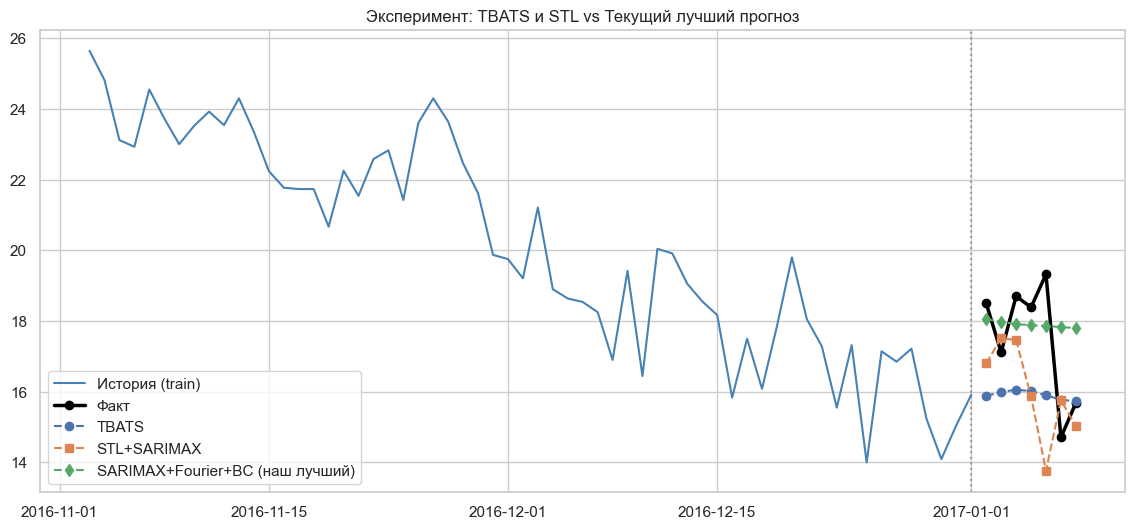

In [54]:
# ============================================================
# ЭКСПЕРИМЕНТ: TBATS и STL+SARIMAX
# ============================================================

from tbats import TBATS, BATS
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.arima.model import ARIMA

# --- 1. TBATS ---
print("Обучение TBATS...")
# Указываем две сезонности: недельную (7) и годовую (365.25)
# Отключаем Box-Cox и ARMA для скорости, как рекомендует документация
tbats = TBATS(
    seasonal_periods=[7, 365.25],
    use_box_cox=False,
    use_arma_errors=False,
    n_jobs=1  # Для стабильности на некоторых системах
)
tbats_model = tbats.fit(train['meantemp'])
tbats_forecast = tbats_model.forecast(steps=HORIZON)

# --- 2. STL + SARIMAX ---
print("\nОбучение STL + SARIMAX...")
# Создаем модель, которая сначала делает STL-декомпозицию, а затем применяет ARIMA
# seasonal=7 или 365? Для начала попробуем 7, так как STL может быть медленным на 365
stl_forecast_model = STLForecast(
    train['meantemp'],
    model=ARIMA,
    model_kwargs={'order': (1, 1, 1), 'seasonal_order': (1, 0, 1, 7)},
    period=7  # Период для STL-декомпозиции
)
stl_results = stl_forecast_model.fit()
stl_forecast = stl_results.forecast(steps=HORIZON)

# --- 3. Сравнение с фактом ---
actual = test['meantemp'].iloc[1:1 + HORIZON].values  # 2-8 января 2017

results_experiment = pd.DataFrame({
    'ACTUAL': actual,
    'TBATS': tbats_forecast,
    'STL+SARIMAX': stl_forecast,
}, index=test.index[1:1 + HORIZON])

# Добавляем наш лучший прогноз для сравнения
results_experiment['SARIMAX+Fourier+BC'] = sarimax_bc_t  # из предыдущих ячеек

display(results_experiment.round(2))

print("\nMAPE на 7-дневном горизонте:")
for col in results_experiment.columns:
    if col == 'ACTUAL': continue
    mape_val = calc_mape(actual, results_experiment[col].values)
    print(f"  {col:<25s}: {mape_val:.2f}%")

# --- 4. Визуализация ---
plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train['meantemp'].iloc[-60:], label='История (train)', color='steelblue')
plt.plot(results_experiment.index, actual, '-o', color='black', label='Факт', linewidth=2.5)
plt.plot(results_experiment.index, results_experiment['TBATS'], '--o', label='TBATS')
plt.plot(results_experiment.index, results_experiment['STL+SARIMAX'], '--s', label='STL+SARIMAX')
plt.plot(results_experiment.index, results_experiment['SARIMAX+Fourier+BC'], '--d', label='SARIMAX+Fourier+BC (наш лучший)')
plt.axvline(train.index[-1], color='gray', ls=':', alpha=0.7)
plt.title('Эксперимент: TBATS и STL vs Текущий лучший прогноз')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
# TBATS + bias correction
bias_tbats = backtest_bias(
    lambda s, h: TBATS(seasonal_periods=[7, 365.25],
                       use_box_cox=False, use_arma_errors=False).fit(s).forecast(steps=h),
    train['meantemp'], n_recent=60
)
print(f"TBATS bias: {bias_tbats:+.2f} °C")

tbats_bc = tbats_forecast + bias_tbats
print(f"TBATS+BC MAPE: {calc_mape(actual, tbats_bc):.2f}%")

TBATS bias: -1.97 °C
TBATS+BC MAPE: 19.62%


In [62]:
import numpy as np
import pandas as pd
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# ---------- Config ----------
HORIZON = 7
LAGS = (1, 2, 3, 7, 14)
FOURIER_K = 4


# ---------- Helpers ----------
def fourier(t_idx, K=FOURIER_K, period=365.25):
    t = np.asarray(t_idx, dtype=float)
    return pd.DataFrame({
        **{f'sin_{k}': np.sin(2*np.pi*k*t/period) for k in range(1, K+1)},
        **{f'cos_{k}': np.cos(2*np.pi*k*t/period) for k in range(1, K+1)},
    })


def calc_mape(a, p):
    a, p = np.asarray(a).ravel(), np.asarray(p).ravel()
    return float(np.mean(np.abs((a - p) / a)) * 100)


# ---------- SARIMAX direct ----------
def sarimax_direct(train_series, horizon, bias=0.0):
    exog = fourier(np.arange(len(train_series)))
    m = SARIMAX(
        train_series.values, exog=exog.values,
        order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    t_fut = np.arange(len(train_series), len(train_series) + horizon)
    exog_f = fourier(t_fut)
    fc = m.get_forecast(steps=horizon, exog=exog_f.values)
    return np.asarray(fc.predicted_mean).ravel() + bias


# ---------- Prophet recursive ----------
def forecast_prophet(df_train, horizon, bias=0.0, lags=LAGS):
    """Рекурсивный прогноз: предсказание идёт в лаг следующего шага."""
    df = df_train.reset_index()
    date_col = df.columns[0]
    df = df[[date_col, 'meantemp']].rename(columns={date_col: 'ds', 'meantemp': 'y'})
    for l in lags:
        df[f'lag_{l}'] = df['y'].shift(l)
    df = df.dropna().reset_index(drop=True)

    m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.01,
                seasonality_prior_scale=0.1)
    for l in lags:
        m.add_regressor(f'lag_{l}')
    m.fit(df)

    last_ds = df['ds'].iloc[-1]
    last_y = list(df['y'].values)
    means, los, his = [], [], []
    for h in range(1, horizon + 1):
        row = {'ds': last_ds + pd.Timedelta(days=h)}
        for l in lags:
            row[f'lag_{l}'] = last_y[-l]
        pred = m.predict(pd.DataFrame([row]))
        means.append(pred['yhat'].iloc[0])
        los.append(pred['yhat_lower'].iloc[0])
        his.append(pred['yhat_upper'].iloc[0])
        last_y.append(pred['yhat'].iloc[0])

    return (np.array(means) + bias,
            np.column_stack([np.array(los) + bias, np.array(his) + bias]))


# ---------- Prophet direct (по одной модели на каждый h) ----------
def prophet_direct_models(train_df, horizon, lags=LAGS):
    """
    Для каждого h = 1..horizon обучает отдельную Prophet-модель на
    разреженном ряде (шаг h). Прогноз на h дней вперёд использует
    только лаги из фактических данных, без каскада.
    """
    df = train_df.reset_index()
    date_col = df.columns[0]
    df = df[[date_col, 'meantemp']].rename(columns={date_col: 'ds', 'meantemp': 'y'})

    predictions = {}
    for h in range(1, horizon + 1):
        df_h = df.iloc[::h].copy().reset_index(drop=True)
        for l in lags:
            df_h[f'lag_{l}'] = df_h['y'].shift(l)
        df_h = df_h.dropna().reset_index(drop=True)

        if len(df_h) < 30:  # мало данных для обучения
            predictions[h] = df['y'].iloc[-1]
            continue

        m = Prophet(daily_seasonality=False, weekly_seasonality=False,
                    yearly_seasonality=True, changepoint_prior_scale=0.01,
                    seasonality_prior_scale=0.1)
        for l in lags:
            m.add_regressor(f'lag_{l}')
        m.fit(df_h)

        row = {'ds': df['ds'].iloc[-1] + pd.Timedelta(days=h)}
        for l in lags:
            idx = -l * h
            row[f'lag_{l}'] = df['y'].iloc[idx] if abs(idx) <= len(df) else df['y'].iloc[0]

        yhat = m.predict(pd.DataFrame([row]))['yhat'].iloc[0]
        predictions[h] = yhat

    return np.array([predictions[h] for h in range(1, horizon + 1)])


# ---------- Walk-forward comparison ----------
def walk_forward_compare(train_init, test_df, horizon=HORIZON,
                          bias_sar=0.0, bias_pro=0.0):
    history = train_init.copy()
    results = []
    pos = 0
    wid = 0
    while pos < len(test_df):
        end = min(pos + horizon, len(test_df))
        block_h = end - pos
        wid += 1
        print(f"  Окно {wid}: обучение до {history.index[-1].date()}, "
              f"прогноз на {block_h} дней")

        sar_m = sarimax_direct(history['meantemp'], block_h, bias=bias_sar)
        pro_rec = forecast_prophet(history, block_h, bias_pro)[0]
        pro_dir = prophet_direct_models(history, block_h) + bias_pro

        for i in range(block_h):
            results.append({
                'date':        test_df.index[pos + i],
                'h':           i + 1,
                'actual':      test_df.iloc[pos + i]['meantemp'],
                'sarimax':     sar_m[i],
                'prophet_rec': pro_rec[i],
                'prophet_dir': pro_dir[i],
            })

        history = pd.concat([history, test_df.iloc[pos:end]])
        pos = end

    return pd.DataFrame(results).set_index('date')

Walk-forward: recursive vs direct (10–20 мин)...
  Окно 1: обучение до 2017-01-01, прогноз на 7 дней


15:23:28 - cmdstanpy - INFO - Chain [1] start processing
15:23:28 - cmdstanpy - INFO - Chain [1] done processing
15:23:28 - cmdstanpy - INFO - Chain [1] start processing
15:23:28 - cmdstanpy - INFO - Chain [1] done processing
15:23:29 - cmdstanpy - INFO - Chain [1] start processing
15:23:29 - cmdstanpy - INFO - Chain [1] done processing
15:23:29 - cmdstanpy - INFO - Chain [1] start processing
15:23:29 - cmdstanpy - INFO - Chain [1] done processing
15:23:29 - cmdstanpy - INFO - Chain [1] start processing
15:23:29 - cmdstanpy - INFO - Chain [1] done processing
15:23:29 - cmdstanpy - INFO - Chain [1] start processing
15:23:29 - cmdstanpy - INFO - Chain [1] done processing
15:23:30 - cmdstanpy - INFO - Chain [1] start processing
15:23:30 - cmdstanpy - INFO - Chain [1] done processing
15:23:30 - cmdstanpy - INFO - Chain [1] start processing
15:23:30 - cmdstanpy - INFO - Chain [1] done processing


  Окно 2: обучение до 2017-01-07, прогноз на 7 дней


15:23:34 - cmdstanpy - INFO - Chain [1] start processing
15:23:35 - cmdstanpy - INFO - Chain [1] done processing
15:23:35 - cmdstanpy - INFO - Chain [1] start processing
15:23:35 - cmdstanpy - INFO - Chain [1] done processing
15:23:35 - cmdstanpy - INFO - Chain [1] start processing
15:23:35 - cmdstanpy - INFO - Chain [1] done processing
15:23:36 - cmdstanpy - INFO - Chain [1] start processing
15:23:36 - cmdstanpy - INFO - Chain [1] done processing
15:23:36 - cmdstanpy - INFO - Chain [1] start processing
15:23:36 - cmdstanpy - INFO - Chain [1] done processing
15:23:36 - cmdstanpy - INFO - Chain [1] start processing
15:23:36 - cmdstanpy - INFO - Chain [1] done processing
15:23:36 - cmdstanpy - INFO - Chain [1] start processing
15:23:36 - cmdstanpy - INFO - Chain [1] done processing
15:23:37 - cmdstanpy - INFO - Chain [1] start processing
15:23:37 - cmdstanpy - INFO - Chain [1] done processing


  Окно 3: обучение до 2017-01-14, прогноз на 7 дней


...

  Окно 16: обучение до 2017-04-15, прогноз на 7 дней


15:25:27 - cmdstanpy - INFO - Chain [1] start processing
15:25:27 - cmdstanpy - INFO - Chain [1] done processing
15:25:27 - cmdstanpy - INFO - Chain [1] start processing
15:25:28 - cmdstanpy - INFO - Chain [1] done processing
15:25:28 - cmdstanpy - INFO - Chain [1] start processing
15:25:28 - cmdstanpy - INFO - Chain [1] done processing
15:25:28 - cmdstanpy - INFO - Chain [1] start processing
15:25:28 - cmdstanpy - INFO - Chain [1] done processing
15:25:28 - cmdstanpy - INFO - Chain [1] start processing
15:25:28 - cmdstanpy - INFO - Chain [1] done processing
15:25:29 - cmdstanpy - INFO - Chain [1] start processing
15:25:29 - cmdstanpy - INFO - Chain [1] done processing
15:25:29 - cmdstanpy - INFO - Chain [1] start processing
15:25:29 - cmdstanpy - INFO - Chain [1] done processing
15:25:29 - cmdstanpy - INFO - Chain [1] start processing
15:25:29 - cmdstanpy - INFO - Chain [1] done processing


  Окно 17: обучение до 2017-04-22, прогноз на 2 дней


15:25:35 - cmdstanpy - INFO - Chain [1] start processing
15:25:35 - cmdstanpy - INFO - Chain [1] done processing
15:25:35 - cmdstanpy - INFO - Chain [1] start processing
15:25:35 - cmdstanpy - INFO - Chain [1] done processing
15:25:36 - cmdstanpy - INFO - Chain [1] start processing
15:25:36 - cmdstanpy - INFO - Chain [1] done processing



✅ Готово: 114 прогнозов

MAPE по горизонту (h = 1..7):
h       SARIMAX   Proph_rec   Proph_dir
----------------------------------------
1         8.05%       7.69%       7.93%
2        10.14%      10.41%      10.52%
3        12.86%      13.43%      14.02%
4        15.64%      16.49%      16.67%
5        11.11%      11.45%      10.50%
6        14.72%      14.74%      14.84%
7        14.51%      14.37%      12.23%

Общий MAPE на 114 днях:
  sarimax        : MAE=2.242  MAPE=12.38%
  prophet_rec    : MAE=2.282  MAPE=12.59%
  prophet_dir    : MAE=2.277  MAPE=12.33%


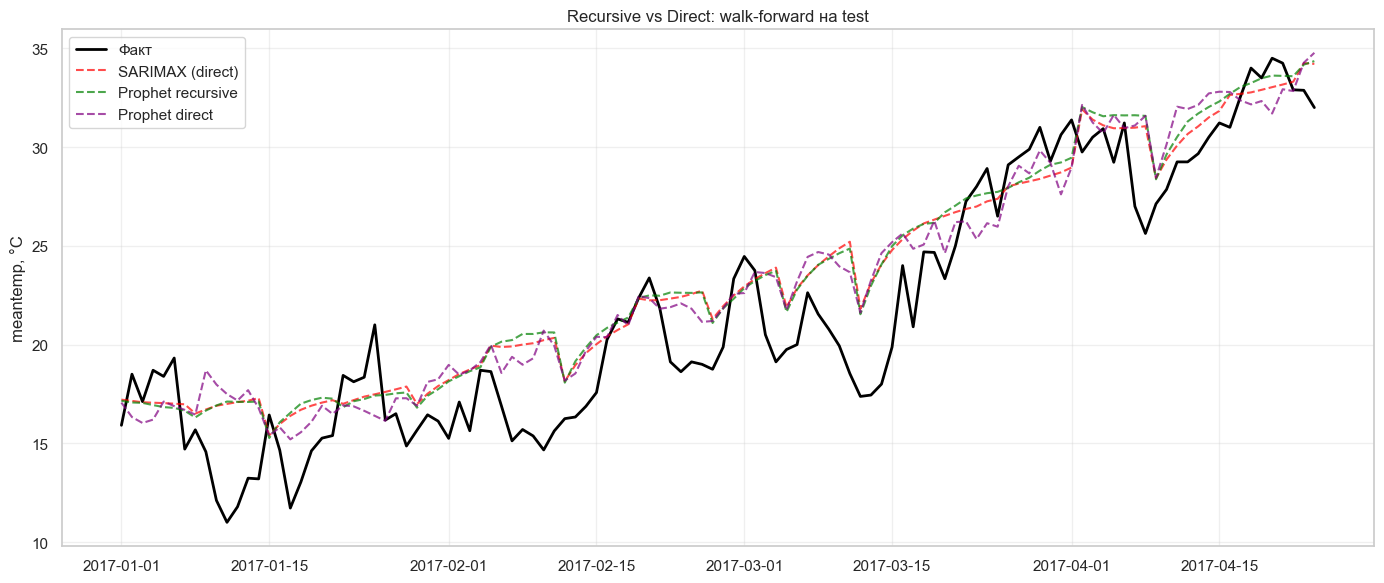

In [63]:
print("Walk-forward: recursive vs direct (10–20 мин)...")
cmp = walk_forward_compare(train, test, HORIZON,
                            bias_sar=bias_sar,    # из предыдущих ячеек
                            bias_pro=bias_pro)
print(f"\n✅ Готово: {len(cmp)} прогнозов")

# MAPE по горизонту
print("\n" + "=" * 60)
print("MAPE по горизонту (h = 1..7):")
print("=" * 60)
print(f"{'h':<3s}{'SARIMAX':>12s}{'Proph_rec':>12s}{'Proph_dir':>12s}")
print("-" * 40)
for h in range(1, HORIZON + 1):
    sl = cmp[cmp['h'] == h]
    print(f"{h:<3d}"
          f"{calc_mape(sl['actual'], sl['sarimax']):>11.2f}%"
          f"{calc_mape(sl['actual'], sl['prophet_rec']):>11.2f}%"
          f"{calc_mape(sl['actual'], sl['prophet_dir']):>11.2f}%")

# Общий MAPE
print("\nОбщий MAPE на 114 днях:")
for col in ['sarimax', 'prophet_rec', 'prophet_dir']:
    mae = mean_absolute_error(cmp['actual'], cmp[col])
    mape = calc_mape(cmp['actual'], cmp[col])
    print(f"  {col:<15s}: MAE={mae:.3f}  MAPE={mape:.2f}%")

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(cmp.index, cmp['actual'], '-', color='black', linewidth=2, label='Факт')
plt.plot(cmp.index, cmp['sarimax'], '--', color='red', alpha=0.7, label='SARIMAX (direct)')
plt.plot(cmp.index, cmp['prophet_rec'], '--', color='green', alpha=0.7, label='Prophet recursive')
plt.plot(cmp.index, cmp['prophet_dir'], '--', color='purple', alpha=0.7, label='Prophet direct')
plt.title('Recursive vs Direct: walk-forward на test')
plt.ylabel('meantemp, °C')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()